<a href="https://colab.research.google.com/github/Rakib007Nabila/Detection-of-Parkinsons-Using-ML/blob/main/Paper_for_WSN_Energy_Optimization_10_09_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LEACH:**

In the LEACH protocol, Cluster Heads (CHs) are selected randomly each round from the set of alive nodes.

**Setup Phase:**

Probability of a node becoming a cluster head:

P_CH(t) = 𝑝/(1 − 𝑝 × (𝑚𝑜𝑑(𝑡,𝑖/𝑝)))

• P_CH(t) is the probability of a node becoming a cluster head at round
• p is the desired percentage of cluster heads.
• mod represents the modulo operation.

-	Decision-making by node n that selects a random number between 0 and 1. If the number is less than the threshold limit, then the node becomes CH for the session.

-	After the node acts as CH, the node will announce the message to the remaining non-CH nodes remaining. The non-CH node receives the message and will tell the CH to join as a member of the cluster. Cluster member selection criteria can be based on the **signal strength** received by non CH nodes and many other factors. After receiving the merge information, CH forms a TDMA schedule and propagate to all nodes. The TDMA schedule divides the time into many slots, where the number of slots are equals as the number of nodes in the cluster.


**Steady Sate Phase:**

the process of data transfer between nodes uses transmission and observation activities.

These CHs will:
•	Receive data from their cluster members

•	Aggregate it

•	Transmit it to the Base Station.


!!!!**Event detection confusion:**!!!!

•	All nodes transmit data to their CHs in every round, regardless of whether an event is detected or not.

•	CHs then aggregate the data and send it to the Base Station (BS).

Each round consumes energy for:
 - Transmission from non-CH nodes to CHs.
 -	Reception and aggregation by CHs.
 - Transmission from CHs to BS.


Round 100: 100 nodes alive, 
Round 200: 100 nodes alive, 
Round 300: 100 nodes alive, 
Round 400: 100 nodes alive, 
Round 500: 100 nodes alive, 
Round 600: 98 nodes alive, 
Round 700: 95 nodes alive, 
Round 800: 84 nodes alive, 
Round 900: 76 nodes alive, 
Round 1000: 70 nodes alive, 
Round 1100: 64 nodes alive, 
Round 1200: 61 nodes alive, 
Round 1300: 55 nodes alive, 
Round 1400: 53 nodes alive, 
Round 1500: 47 nodes alive, 
Round 1600: 39 nodes alive, 
Simulation complete.
First Node Death (FND): 552
Last Node Death (LND): 1692


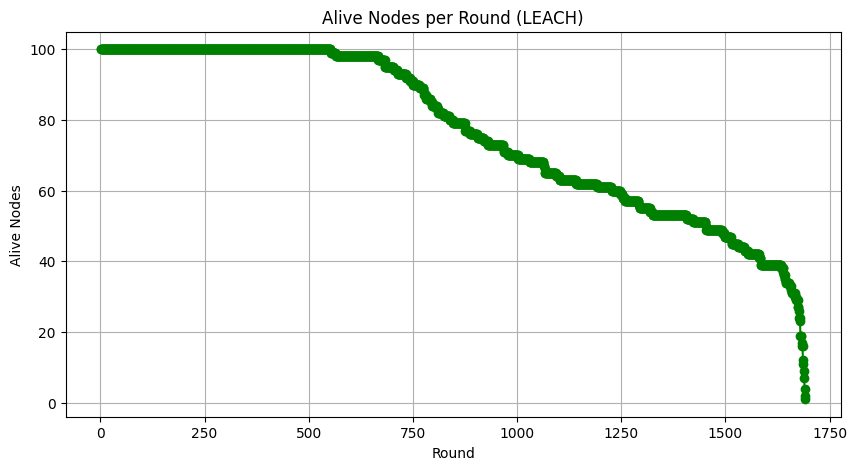

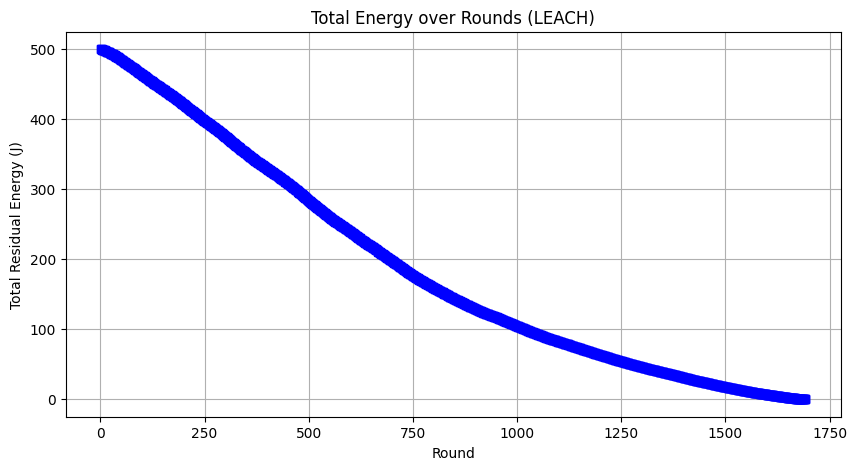

In [ ]:
# LEACH following the paper parameters
import numpy as np
import random
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1            # desired CH probability
M_SESSIONS = 15     # number of TDMA frames (sessions) per round, set >1 to simulate more traffic

# Radio model parameters
E_ELEC = 50e-9       # J/bit
E_DA   = 5e-9        # J/bit
E_AMP  = 100e-12     # J/bit/m^2

# Packet sizes
K_DATA = 100 * 8     # 100 bytes = 800 bits
K_CTRL = 20 * 8      # 20 bytes = 160 bits

# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

# CH energy Eq.(2)
def energy_CH(n,m,d_bs, d_cluster, ):
    E_adv = energy_tx(K_CTRL, d_cluster)                  # ADV broadcast
    E_join_rx = n * energy_rx(K_CTRL)                     # receive JOIN from n nodes
    E_tdma = energy_tx(K_CTRL, d_cluster)                 # TDMA schedule broadcast
    E_data_rx = n * m * energy_rx(K_DATA)  # receive m packets from each of n members
    E_data_agg = n * m * energy_da(K_DATA) +  m * energy_tx(K_DATA, d_bs)  # aggregate & forward m packets
    return E_adv + E_join_rx + E_tdma + E_data_rx + E_data_agg

# Node energy Eq.(3)
def energy_node(p, m, d_ch):
    E_adv_rx = p * energy_rx(K_CTRL)                      # receive ADV from p CHs
    E_join_tx = energy_tx(K_CTRL, d_ch)                   # send JOIN to CH
    E_tdma_rx = energy_rx(K_CTRL)                         # receive TDMA schedule
    E_data_tx = m * energy_tx(K_DATA, d_ch)               # transmit m packets to CH
    return E_adv_rx + E_join_tx + E_tdma_rx + E_data_tx

# ==============================
# Helper function
# ==============================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# Node deployment
# ==============================
SEED = 42
np.random.seed(SEED)


x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)

node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
death_round = {i: None for i in range(NUM_NODES)}
last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}  # track last CH round

alive_node_count_per_round = []
total_energy_per_round = []

# ==============================
# Simulation loop
# ==============================
round_num = 0
while any(e > 0 for e in node_energy.values()):
    round_num += 1
    alive_nodes = [i for i, e in node_energy.items() if e > 0]

    alive_node_count_per_round.append(len(alive_nodes))
    total_energy_per_round.append(sum(node_energy.values()))

    # --- Original LEACH probabilistic CH selection ---
    selected_ch_ids = []
    G = [n for n in alive_nodes if round_num - last_CH_round[n] >= int(1/P)]
    for node in G:
        T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
        if np.random.rand() < T_n:
            selected_ch_ids.append(node)
            last_CH_round[node] = round_num

    if len(selected_ch_ids) == 0:
        # Ensure at least 1 CH
        max_energy_node = max(alive_nodes, key=lambda n: node_energy[n])
        selected_ch_ids = [max_energy_node]
        last_CH_round[max_energy_node] = round_num

    # --- Assign cluster members ---
    cluster_members = {ch: [] for ch in selected_ch_ids}
    for node_id in alive_nodes:
        if node_id in selected_ch_ids:
            continue
        # Assign to nearest CH
        dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                    x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
        chosen_ch = selected_ch_ids[np.argmin(dists)]
        cluster_members[chosen_ch].append((node_id, min(dists)))

    # --- Update CH energy ---
    for ch in selected_ch_ids:
        if node_energy[ch] <= 0:
            continue
        n = len(cluster_members[ch])  # members
        d_cluster = np.mean([d for _, d in cluster_members[ch]]) if n > 0 else 1
        d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                  base_station[0], base_station[1])
        ECH = energy_CH(n=n, m=M_SESSIONS, d_cluster=d_cluster, d_bs=d_bs)
        node_energy[ch] -= ECH
        if node_energy[ch] <= 0 and death_round[ch] is None:
            death_round[ch] = round_num

    # --- Update ordinary nodes energy ---
    for ch, members in cluster_members.items():
        for node_id, d_ch in members:
            if node_energy[node_id] <= 0:
                continue
            p = len(selected_ch_ids)  # nodes hear ADV from all CHs
            EON = energy_node(p=p, m=M_SESSIONS, d_ch=d_ch)
            node_energy[node_id] -= EON
            if node_energy[node_id] <= 0 and death_round[node_id] is None:
                death_round[node_id] = round_num

    if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} nodes alive, ")

# ==============================
# Results
# ==============================
FND = min(death_round.values())
LND = max(death_round.values())

print("Simulation complete.")
print(f"First Node Death (FND): {FND}")
print(f"Last Node Death (LND): {LND}")

# --- Plot Alive Nodes ---
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_node_count_per_round)+1), alive_node_count_per_round, marker='o', color='green')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title(f"Alive Nodes per Round (LEACH)")
plt.grid(True)
plt.show()

# --- Plot Total Energy ---
plt.figure(figsize=(10,5))
plt.plot(range(1,len(total_energy_per_round)+1), total_energy_per_round, marker='s', color='blue')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title(f"Total Energy over Rounds (LEACH)")
plt.grid(True)
plt.show()


Round 100: 100 node(s) alive
Round 200: 100 node(s) alive
Round 300: 100 node(s) alive
Round 400: 100 node(s) alive
Round 500: 100 node(s) alive
Round 600: 98 node(s) alive
Round 700: 95 node(s) alive
Round 800: 84 node(s) alive
Round 900: 75 node(s) alive
Round 1000: 69 node(s) alive
Round 1100: 65 node(s) alive
Round 1200: 61 node(s) alive
Round 1300: 55 node(s) alive
Round 1400: 53 node(s) alive
Round 1500: 48 node(s) alive
Round 1600: 38 node(s) alive
Round 100: 100 node(s) alive
Round 200: 100 node(s) alive
Round 300: 100 node(s) alive
Round 400: 100 node(s) alive
Round 500: 100 node(s) alive
Round 600: 100 node(s) alive
Round 700: 98 node(s) alive
Round 800: 97 node(s) alive
Round 900: 93 node(s) alive
Round 1000: 87 node(s) alive
Round 1100: 84 node(s) alive
Round 1200: 79 node(s) alive
Round 1300: 73 node(s) alive
Round 1400: 64 node(s) alive
Round 1500: 57 node(s) alive
Round 1600: 52 node(s) alive
Round 1700: 36 node(s) alive
LEACH: FND = 554 LND = 1683
ES-MAC: FND = 632 LND 

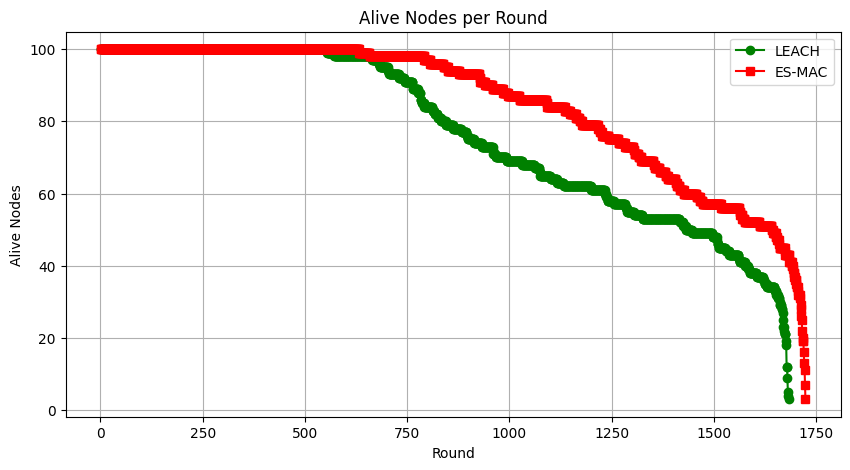

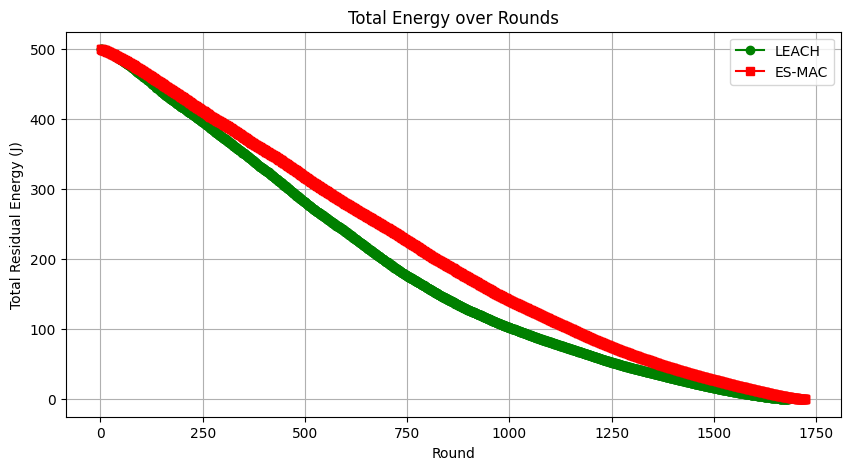

In [ ]:
# LEACH and ES-MAC combined

import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1
M_SESSIONS = 15
P_DATA = 0.9  # probability of having data per session in ES-MAC

# Radio model parameters
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# ==============================
# Node positions
# ==============================
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)




# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

# ==============================
# Helper
# ==============================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# ==============================
# Simulation function
# ==============================
def run_leach_vs_esmac(esmac=False):


    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0


    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]

        # --- progress indicator every 100 rounds ---
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} node(s) alive")


        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        selected_ch_ids = []
        G = [n for n in alive_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            T_n = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < T_n:
                selected_ch_ids.append(node)
                last_CH_round[node] = round_num
        if len(selected_ch_ids) == 0:
            #pick the alive node with maximum residual energy
            max_energy_node = max(alive_nodes, key=lambda n: node_energy[n])
            selected_ch_ids = [max_energy_node]
            last_CH_round[max_energy_node] = round_num

        # --- Assign members ---
        cluster_members = {ch: [] for ch in selected_ch_ids}
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            dists = [calculate_distance(x_positions[node_id], y_positions[node_id],
                                        x_positions[ch], y_positions[ch]) for ch in selected_ch_ids]
            chosen_ch = selected_ch_ids[np.argmin(dists)]
            cluster_members[chosen_ch].append((node_id, min(dists)))

        # --- Setup phase energy ---
        for node_id in alive_nodes:
            if node_id in selected_ch_ids:
                continue
            d_ch = min([calculate_distance(x_positions[node_id], y_positions[node_id],
                                           x_positions[ch], y_positions[ch]) for ch in selected_ch_ids])
            node_energy[node_id] -= (len(selected_ch_ids) * energy_rx(K_CTRL)
                                     + energy_tx(K_CTRL, d_ch)
                                     + energy_rx(K_CTRL))
            if node_energy[node_id] <= 0 and death_round[node_id] is None:
                death_round[node_id] = round_num

        for ch in selected_ch_ids:
            # CH broadcast distance
            if cluster_members[ch]:
                d_cluster = max([calculate_distance(x_positions[ch], y_positions[ch],
                                                    x_positions[n], y_positions[n]) for n, _ in cluster_members[ch]])
            else:
                # single node or no members: use a conservative distance to base station
                d_cluster = calculate_distance(x_positions[ch], y_positions[ch],
                                               base_station[0], base_station[1])
            n_members = len(cluster_members[ch])
            node_energy[ch] -= (energy_tx(K_CTRL, d_cluster)
                                + n_members * energy_rx(K_CTRL)
                                + energy_tx(K_CTRL, d_cluster))
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num


        # --- Session loop (data transmission) ---
        for session in range(M_SESSIONS):
            #P_DATA = np.random.random()  # probability of having data per session in ES-MAC
            member_transmissions = {ch: [] for ch in selected_ch_ids}
            for ch, members in cluster_members.items():
                for node_id, d_ch in members:
                    if node_energy[node_id] <= 0:
                        continue
                    if esmac:
                        has_data = np.random.random() < P_DATA
                    else:
                        has_data = True
                    if has_data:
                        node_energy[node_id] -= energy_tx(K_DATA, d_ch)
                        member_transmissions[ch].append(node_id)
                        if node_energy[node_id] <= 0 and death_round[node_id] is None:
                            death_round[node_id] = round_num

            for ch in selected_ch_ids:
                if node_energy[ch] <= 0:
                    continue
                num_recv = len(member_transmissions[ch])
                E_data_rx = num_recv * energy_rx(K_DATA)
                E_data_agg = num_recv * energy_da(K_DATA)
                if num_recv > 0:
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                              base_station[0], base_station[1])
                    E_tx_to_bs = energy_tx(K_DATA, d_bs)
                else:
                    # single node or no members: transmit one status packet to BS
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                              base_station[0], base_station[1])
                    E_tx_to_bs = energy_tx(K_DATA, d_bs)  # self data packet
                    E_data_agg = energy_da(K_DATA)
                    E_data_rx = 0

                node_energy[ch] -= (E_data_rx + E_data_agg + E_tx_to_bs)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num



    return alive_node_count_per_round, total_energy_per_round, death_round




# ==============================
# Run simulations
# ==============================
alive_leach, energy_leach, death_leach = run_leach_vs_esmac(esmac=False)
alive_esmac, energy_esmac, death_esmac = run_leach_vs_esmac(esmac=True)


FND_leach = min(death_leach.values())
LND_leach = max(death_leach.values())
FND_esmac = min(death_esmac.values())
LND_esmac = max(death_esmac.values())

print("LEACH: FND =", FND_leach, "LND =", LND_leach)
print("ES-MAC: FND =", FND_esmac, "LND =", LND_esmac)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_leach)+1), alive_leach, marker='o', color='green', label='LEACH')
plt.plot(range(1,len(alive_esmac)+1), alive_esmac, marker='s', color='red', label='ES-MAC')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_leach)+1), energy_leach, marker='o', color='green', label='LEACH')
plt.plot(range(1,len(energy_esmac)+1), energy_esmac, marker='s', color='red', label='ES-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds")
plt.grid(True)
plt.legend()
plt.show()


Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 100 alive
Round 800: 100 alive
Round 900: 100 alive
Round 1000: 99 alive
Round 1100: 98 alive
Round 1200: 94 alive
Round 1300: 93 alive
Round 1400: 87 alive
Round 1500: 84 alive
Round 1600: 81 alive
Round 1700: 73 alive
Round 1800: 65 alive
Round 1900: 59 alive
Round 2000: 54 alive
Round 2100: 50 alive
Round 2200: 47 alive
Round 2300: 45 alive
Round 2400: 40 alive
Round 2500: 39 alive
Round 2600: 36 alive
Round 2700: 35 alive
Round 2800: 35 alive
Round 2900: 33 alive
Round 3000: 32 alive
Round 3100: 31 alive
Round 3200: 26 alive
Round 3300: 26 alive
Round 3400: 24 alive
Round 3500: 22 alive
Round 3600: 20 alive
EE-MAC: FND = 989 LND = 3660


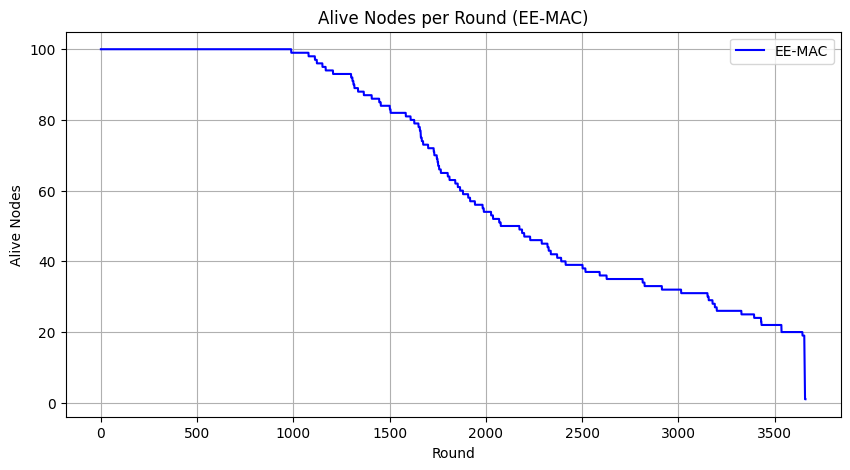

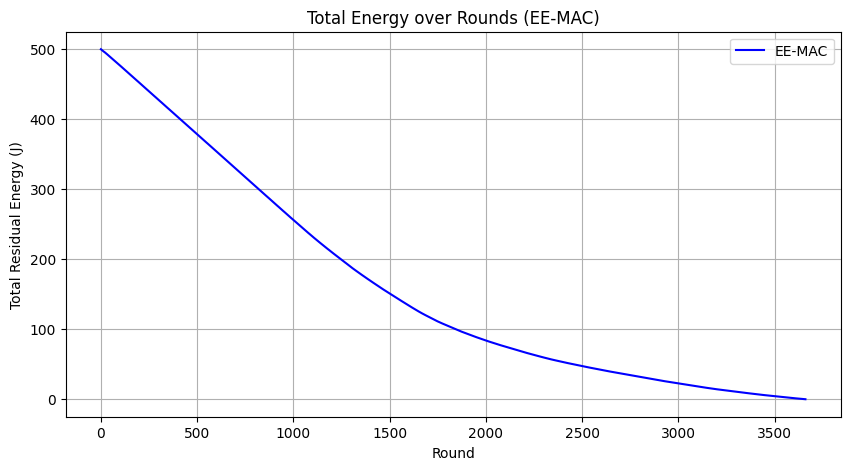

In [ ]:
# EE-MAC Simulation Final
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1               # desired CH probability
M_SESSIONS = 15       # TDMA sessions per round
TE = 1              # threshold energy
PT = 10               # proximity threshold
MCS = 10              # max cluster size

P_DATA_SESSION = 0.9  # probability of having data per session
# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Node positions
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)



# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def broadcast_radius_for_ch(ch, members):
    """Compute conservative radius to reach members"""
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])

    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# ==============================
# EE-MAC Simulation
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        candidate_nodes = [n for n in alive_nodes if node_energy[n] > TE]
        selected_chs = []
        G = [n for n in candidate_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            Tn = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < Tn:
                selected_chs.append(node)
                last_CH_round[node] = round_num

        if len(selected_chs) == 0:
            if candidate_nodes:
              # pick candidate with maximum residual energy
              pick = max(candidate_nodes, key=lambda n: node_energy[n])
            else:
              pick = max(alive_nodes, key=lambda n: node_energy[n])
            selected_chs = [pick]
            last_CH_round[pick] = round_num

        # --- Proximity threshold adjustment ---
        final_chs = []
        for ch in selected_chs:
            too_close = False
            for other in final_chs:
                if calculate_distance(x_positions[ch], y_positions[ch],
                                      x_positions[other], y_positions[other]) < PT:
                    too_close = True
                    break
            if not too_close:
                final_chs.append(ch)



        # CHs broadcast an ADV (control) packet; non-CH nodes receive ADVs.
        # -----------------------------
        # For each CH: broadcast distance set conservatively to farthest alive node (or BS fallback)
        for ch in final_chs:
            # compute conservative broadcast radius to reach all alive nodes except self
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])

            node_energy[ch] -= energy_tx(K_CTRL, d_adv)   # <-- ADV transmit energy
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For each non-CH alive node: receive p ADV packets (p = number of final_chs)
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)   # <-- ADV receive energy (p ADVs)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Join Requests + ACK loop ---
        max_attempts = len(final_chs)
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node]:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK for all requesters (accepted + rejected)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = broadcast_radius_for_ch(ch, all_requesters)
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)

                for n in all_requesters:
                  if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                      death_round[n] = round_num



                    for n in newly_accepted:
                      if node_energy[n] > 0:
                        node_assigned_flag[n] = True
                      else:
                        # node died while receiving ACK — it remains in 'assigned' list but is dead
                        pass

                # --- handle rejected nodes explicitly ---
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                  attempt_index[n] += 1



        # --- TDMA broadcast ---
        for ch in final_chs:
            d_bcast = broadcast_radius_for_ch(ch, assigned[ch])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num


        # --- Steady-state data phase ---
        for session in range(M_SESSIONS):

            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    # decide if node has data this session
                    if np.random.random() < P_DATA_SESSION:
                      d = calculate_distance(x_positions[n], y_positions[n],
                                           x_positions[ch], y_positions[ch])
                      node_energy[n] -= energy_tx(K_DATA, d)
                      recv_nodes.append(n)
                      if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

                num_recv = len(recv_nodes)
                if num_recv > 0:
                   E_rx = num_recv * energy_rx(K_DATA)
                   E_agg = num_recv * energy_da(K_DATA)
                   d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                          base_station[0], base_station[1])
                   E_tx_bs = energy_tx(K_DATA, d_bs)
                   node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                   if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

            # --- Fallback nodes transmit directly to BS each session ---
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
              if node_energy[n] <= 0:
                continue
              if np.random.random() < P_DATA_SESSION:
                d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                node_energy[n] -= energy_tx(K_DATA, d_bs)
                if node_energy[n] <= 0 and death_round[n] is None:
                  death_round[n] = round_num

        # --- Energy floor enforcement ---
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# ==============================
# Run simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eemac()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
FND_eemac = min(death_round_values)
LND_eemac = max(death_round_values)

print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()


Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 100 alive
Round 800: 100 alive
Round 900: 100 alive
Round 1000: 99 alive
Round 1100: 98 alive
Round 1200: 94 alive
Round 1300: 92 alive
Round 1400: 87 alive
Round 1500: 83 alive
Round 1600: 80 alive
Round 1700: 73 alive
Round 1800: 65 alive
Round 1900: 58 alive
Round 2000: 53 alive
Round 2100: 50 alive
Round 2200: 46 alive
Round 2300: 41 alive
Round 2400: 38 alive
Round 2500: 37 alive
Round 2600: 35 alive
Round 2700: 34 alive
Round 2800: 32 alive
Round 2900: 31 alive
Round 3000: 30 alive
Round 3100: 27 alive
Round 3200: 26 alive
Round 3300: 24 alive
Round 3400: 18 alive
Round 3500: 18 alive
Round 3600: 18 alive
Round 3700: 18 alive
Round 3800: 18 alive
Round 3900: 17 alive
Round 4000: 15 alive
Round 4100: 12 alive
Round 4200: 10 alive
Round 4300: 10 alive
Round 4400: 9 alive
Round 4500: 8 alive
Round 4600: 7 alive
EE-MAC: FND = 986 LND = 4664


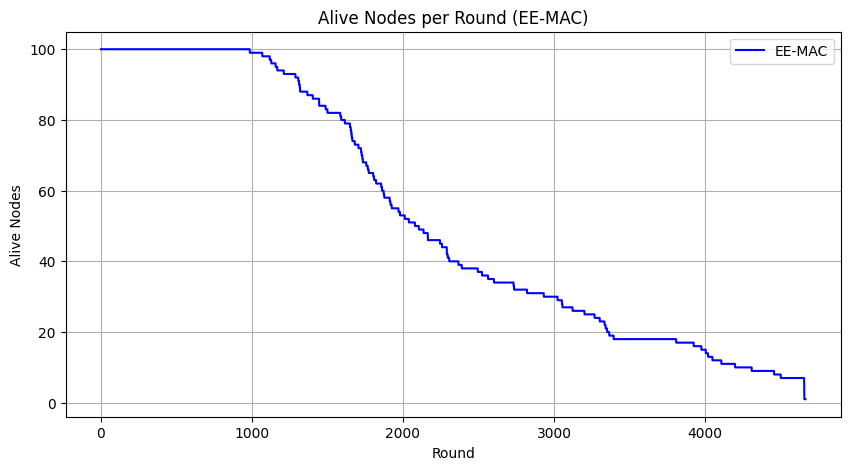

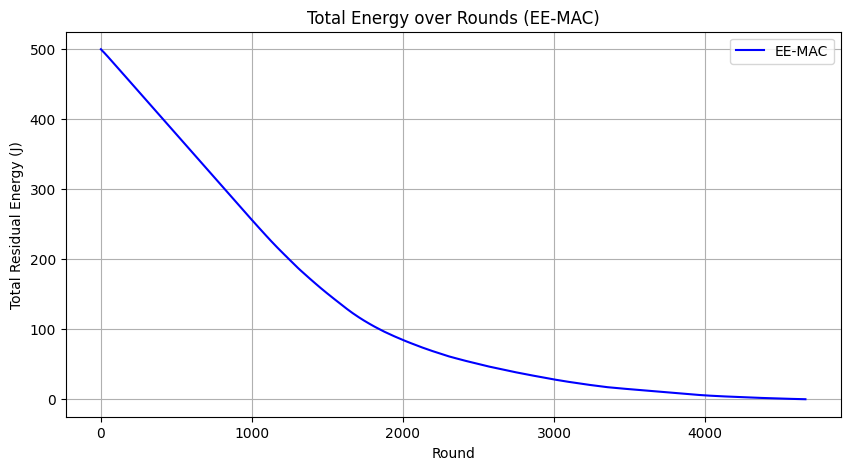

In [ ]:
# EE-MAC Simulation Final (adaptive MCS) (improve performance for LND)
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1               # desired CH probability
M_SESSIONS = 15       # TDMA sessions per round
TE = 1              # threshold energy
PT = 10               # proximity threshold
MCS = 10              # max cluster size

P_DATA_SESSION = 0.9  # probability of having data per session
# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Node positions
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)



# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def broadcast_radius_for_ch(ch, members):
    """Compute conservative radius to reach members"""
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])

    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# --- C. adaptive MCS per CH (when accepting join requests) ---
def compute_MCS_for_ch(ch, node_energy):
    scale = 1.0
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap



# ==============================
# EE-MAC Simulation
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        candidate_nodes = [n for n in alive_nodes if node_energy[n] > TE]
        selected_chs = []
        G = [n for n in candidate_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            Tn = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < Tn:
                selected_chs.append(node)
                last_CH_round[node] = round_num

        if len(selected_chs) == 0:
            if candidate_nodes:
              # pick candidate with maximum residual energy
              pick = max(candidate_nodes, key=lambda n: node_energy[n])
            else:
              pick = max(alive_nodes, key=lambda n: node_energy[n])
            selected_chs = [pick]
            last_CH_round[pick] = round_num

        # --- Proximity threshold adjustment ---
        final_chs = []
        for ch in selected_chs:
            too_close = False
            for other in final_chs:
                if calculate_distance(x_positions[ch], y_positions[ch],
                                      x_positions[other], y_positions[other]) < PT:
                    too_close = True
                    break
            if not too_close:
                final_chs.append(ch)



        # CHs broadcast an ADV (control) packet; non-CH nodes receive ADVs.
        # -----------------------------
        # For each CH: broadcast distance set conservatively to farthest alive node (or BS fallback)
        for ch in final_chs:
            # compute conservative broadcast radius to reach all alive nodes except self
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])

            node_energy[ch] -= energy_tx(K_CTRL, d_adv)   # <-- ADV transmit energy
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For each non-CH alive node: receive p ADV packets (p = number of final_chs)
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)   # <-- ADV receive energy (p ADVs)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Join Requests + ACK loop ---
        max_attempts = len(final_chs)
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node]:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK for all requesters (accepted + rejected)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = broadcast_radius_for_ch(ch, all_requesters)
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)

                for n in all_requesters:
                  if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                      death_round[n] = round_num



                    for n in newly_accepted:
                      if node_energy[n] > 0:
                        node_assigned_flag[n] = True
                      else:
                        # node died while receiving ACK — it remains in 'assigned' list but is dead
                        pass

                # --- handle rejected nodes explicitly ---
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                  attempt_index[n] += 1



        # --- TDMA broadcast ---
        for ch in final_chs:
            d_bcast = broadcast_radius_for_ch(ch, assigned[ch])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num


        # --- Steady-state data phase ---
        for session in range(M_SESSIONS):

            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    # decide if node has data this session
                    if np.random.random() < P_DATA_SESSION:
                      d = calculate_distance(x_positions[n], y_positions[n],
                                           x_positions[ch], y_positions[ch])
                      node_energy[n] -= energy_tx(K_DATA, d)
                      recv_nodes.append(n)
                      if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

                num_recv = len(recv_nodes)
                if num_recv > 0:
                   E_rx = num_recv * energy_rx(K_DATA)
                   E_agg = num_recv * energy_da(K_DATA)
                   d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                          base_station[0], base_station[1])
                   E_tx_bs = energy_tx(K_DATA, d_bs)
                   node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                   if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

            # --- Fallback nodes transmit directly to BS each session ---
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
              if node_energy[n] <= 0:
                continue
              if np.random.random() < P_DATA_SESSION:
                d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                node_energy[n] -= energy_tx(K_DATA, d_bs)
                if node_energy[n] <= 0 and death_round[n] is None:
                  death_round[n] = round_num

        # --- Energy floor enforcement ---
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# ==============================
# Run simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eemac()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
FND_eemac = min(death_round_values)
LND_eemac = max(death_round_values)

print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()


Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 100 alive
Round 800: 100 alive
Round 900: 100 alive
Round 1000: 100 alive
Round 1100: 98 alive
Round 1200: 94 alive
Round 1300: 93 alive
Round 1400: 87 alive
Round 1500: 84 alive
Round 1600: 82 alive
Round 1700: 74 alive
Round 1800: 65 alive
Round 1900: 61 alive
Round 2000: 57 alive
Round 2100: 51 alive
Round 2200: 50 alive
Round 2300: 47 alive
Round 2400: 41 alive
Round 2500: 40 alive
Round 2600: 38 alive
Round 2700: 36 alive
Round 2800: 35 alive
Round 2900: 33 alive
Round 3000: 32 alive
Round 3100: 31 alive
Round 3200: 30 alive
Round 3300: 29 alive
Round 3400: 26 alive
Round 3500: 25 alive
Round 3600: 21 alive
Round 3700: 20 alive
Round 3800: 18 alive
Round 3900: 18 alive
EE-MAC: FND = 1003 LND = 3944


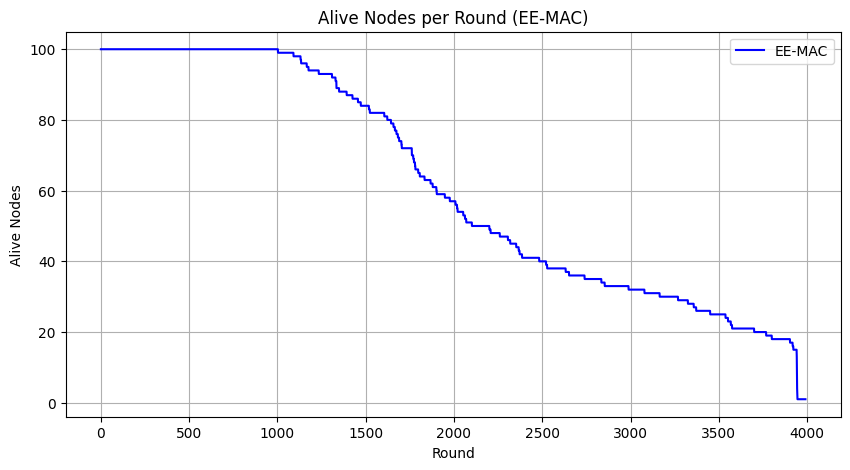

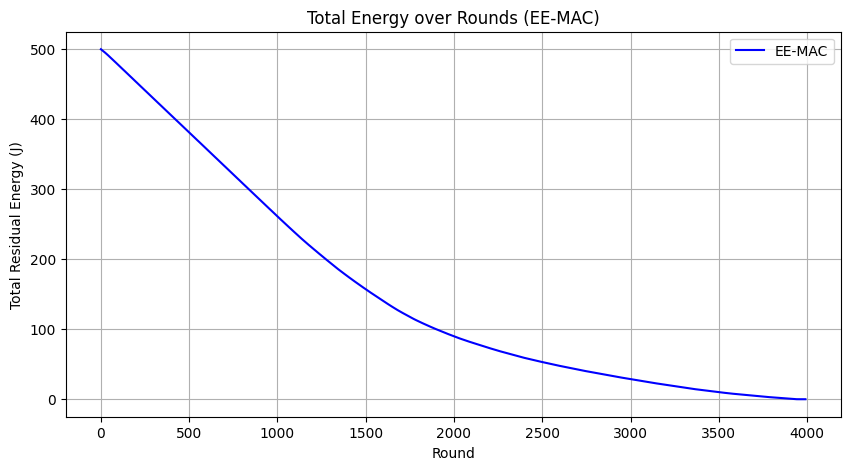

In [ ]:
# EE-MAC Simulation Final (distance aware) ( Performance improves but not significant improvement)
#If a non-CH node finds that the BS is closer than the nearest CH, it should not waste control energy (JOIN/ACK) on cluster formation. Instead, it transmits directly to the BS in the steady state phase.

#This will save energy for nodes near the BS (they skip JOIN/ACK overheads) and will reduce load on CHs, which helps extend lifetime.
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1               # desired CH probability
M_SESSIONS = 15       # TDMA sessions per round
TE = 1                # threshold energy
PT = 10               # proximity threshold
MCS = 10              # max cluster size

P_DATA_SESSION = 0.9  # probability of having data per session
# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Node positions
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)


# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def broadcast_radius_for_ch(ch, members):
    """Compute conservative radius to reach members"""
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# ==============================
# EE-MAC Simulation (Distance-Aware)
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        candidate_nodes = [n for n in alive_nodes if node_energy[n] > TE]
        selected_chs = []
        G = [n for n in candidate_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            Tn = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < Tn:
                selected_chs.append(node)
                last_CH_round[node] = round_num

        if len(selected_chs) == 0:
            if candidate_nodes:
                pick = max(candidate_nodes, key=lambda n: node_energy[n])
            else:
                pick = max(alive_nodes, key=lambda n: node_energy[n])
            selected_chs = [pick]
            last_CH_round[pick] = round_num

        # --- Proximity threshold adjustment ---
        final_chs = []
        for ch in selected_chs:
            too_close = False
            for other in final_chs:
                if calculate_distance(x_positions[ch], y_positions[ch],
                                      x_positions[other], y_positions[other]) < PT:
                    too_close = True
                    break
            if not too_close:
                final_chs.append(ch)

        # --- ADV broadcast energy ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch],
                                           base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # --- Non-CH nodes receive ADV packets ---
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    # Node decides BS is closer → skip join requests
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False  # mark as fallback
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests + ACK loop ---
        max_attempts = len(final_chs)
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = broadcast_radius_for_ch(ch, all_requesters)
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                    if n in newly_accepted and node_energy[n] > 0:
                        node_assigned_flag[n] = True

                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # --- TDMA broadcast ---
        for ch in final_chs:
            d_bcast = broadcast_radius_for_ch(ch, assigned[ch])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # --- Steady-state data phase ---
        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                              base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # --- Fallback nodes transmit directly to BS ---
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n],
                                              base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # --- Energy floor enforcement ---
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round


# ==============================
# Run simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eemac()
death_round_values = [r for r in death_eemac.values() if r is not None]
FND_eemac = min(death_round_values)
LND_eemac = max(death_round_values)
print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()


Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 100 alive
Round 800: 100 alive
Round 900: 100 alive
Round 1000: 100 alive
Round 1100: 97 alive
Round 1200: 95 alive
Round 1300: 95 alive
Round 1400: 92 alive
Round 1500: 89 alive
Round 1600: 81 alive
Round 1700: 80 alive
Round 1800: 72 alive
Round 1900: 68 alive
Round 2000: 65 alive
Round 2100: 63 alive
Round 2200: 58 alive
Round 2300: 54 alive
Round 2400: 50 alive
Round 2500: 47 alive
Round 2600: 47 alive
Round 2700: 44 alive
Round 2800: 44 alive
Round 2900: 37 alive
Round 3000: 36 alive
Round 3100: 35 alive
Round 3200: 34 alive
Round 3300: 33 alive
Round 3400: 33 alive
Round 3500: 31 alive
Round 3600: 29 alive
Round 3700: 28 alive
Round 3800: 27 alive
Round 3900: 23 alive
Round 4000: 18 alive
EE-MAC: FND = 1024 LND = 4004


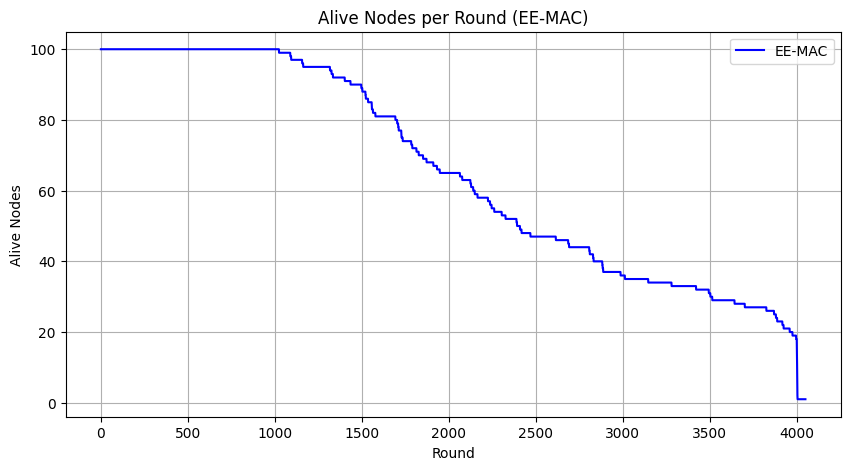

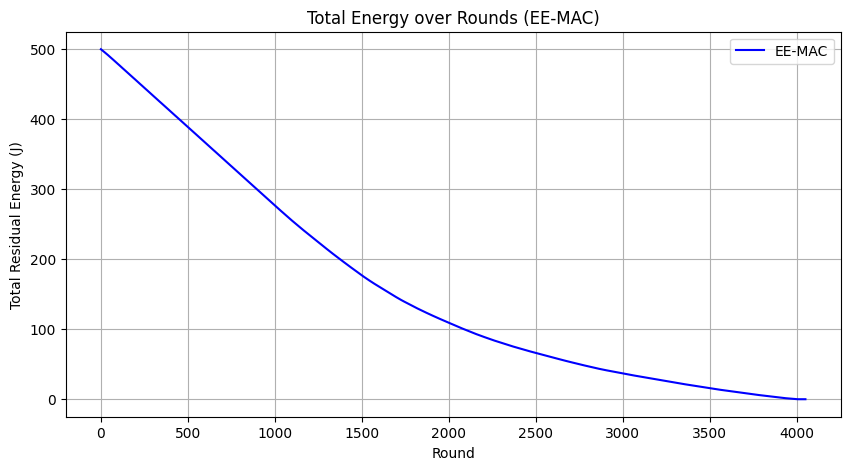

In [ ]:
# EE-MAC Simulation Final (distance aware) ( Duplicate data)
#If a non-CH node finds that the BS is closer than the nearest CH, it should not waste control energy (JOIN/ACK) on cluster formation. Instead, it transmits directly to the BS in the steady state phase.

#This will save energy for nodes near the BS (they skip JOIN/ACK overheads) and will reduce load on CHs, which helps extend lifetime.
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1               # desired CH probability
M_SESSIONS = 15       # TDMA sessions per round
TE = 1                # threshold energy
PT = 10               # proximity threshold
MCS = 10              # max cluster size
P_DUPLICATE = 0.5   # probability two nodes report the same event

P_DATA_SESSION = 0.9  # probability of having data per session
# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Node positions
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)


# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def broadcast_radius_for_ch(ch, members):
    """Compute conservative radius to reach members"""
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# ==============================
# EE-MAC Simulation (Distance-Aware)
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        candidate_nodes = [n for n in alive_nodes if node_energy[n] > TE]
        selected_chs = []
        G = [n for n in candidate_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            Tn = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < Tn:
                selected_chs.append(node)
                last_CH_round[node] = round_num

        if len(selected_chs) == 0:
            if candidate_nodes:
                pick = max(candidate_nodes, key=lambda n: node_energy[n])
            else:
                pick = max(alive_nodes, key=lambda n: node_energy[n])
            selected_chs = [pick]
            last_CH_round[pick] = round_num

        # --- Proximity threshold adjustment ---
        final_chs = []
        for ch in selected_chs:
            too_close = False
            for other in final_chs:
                if calculate_distance(x_positions[ch], y_positions[ch],
                                      x_positions[other], y_positions[other]) < PT:
                    too_close = True
                    break
            if not too_close:
                final_chs.append(ch)

        # --- ADV broadcast energy ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch],
                                           base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # --- Non-CH nodes receive ADV packets ---
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    # Node decides BS is closer → skip join requests
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False  # mark as fallback
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests + ACK loop ---
        max_attempts = len(final_chs)
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = broadcast_radius_for_ch(ch, all_requesters)
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                    if n in newly_accepted and node_energy[n] > 0:
                        node_assigned_flag[n] = True

                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # --- TDMA broadcast ---
        for ch in final_chs:
            d_bcast = broadcast_radius_for_ch(ch, assigned[ch])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # --- Steady-state data phase ---
        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                data_packets = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                        # --- Event data (simulate duplicates) ---
                        if np.random.random() < P_DUPLICATE:
                          event_id = 1   # nodes share the same event
                        else:
                          event_id = n   # unique event per node
                        data_packets.append(event_id)


                if len(data_packets) > 0 :
                    num_recv = len(data_packets)               # all packets received
                    num_unique = len(set(data_packets))        # only unique events
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_unique * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                              base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # --- Fallback nodes transmit directly to BS ---
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n],
                                              base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # --- Energy floor enforcement ---
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round


# ==============================
# Run simulation
# ==============================
alive_eemac, energy_eemac, death_eemac = run_eemac()
death_round_values = [r for r in death_eemac.values() if r is not None]
FND_eemac = min(death_round_values)
LND_eemac = max(death_round_values)
print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, color='blue', label='EE-MAC')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 24.9615 - mae: 2.9299 - val_loss: 8.9570 - val_mae: 1.5165
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 17.2420 - mae: 1.7131 - val_loss: 6.9491 - val_mae: 1.4271
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 15.0602 - mae: 1.5214 - val_loss: 5.5611 - val_mae: 1.1365
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.3386 - mae: 1.1639 - val_loss: 4.4850 - val_mae: 0.8745
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12.0820 - mae: 0.9794 - val_loss: 3.9537 - val_mae: 0.8513
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 11.3809 - mae: 0.9668 - val_loss: 3.5671 - val_mae: 0.7988
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.8038 - mae: 0.8557 - val_loss: 3.0984 - val_mae: 0.6139
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.2175 - mae: 0.7146 - val_loss: 2.7538 - val_mae: 0.5384
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

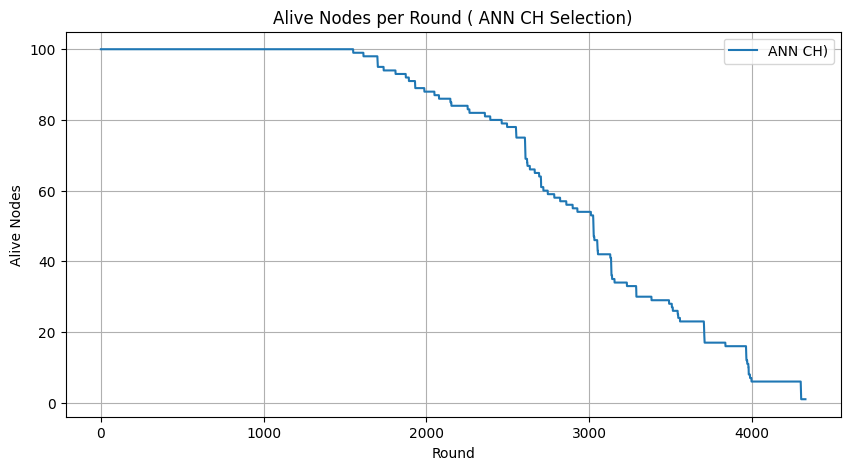

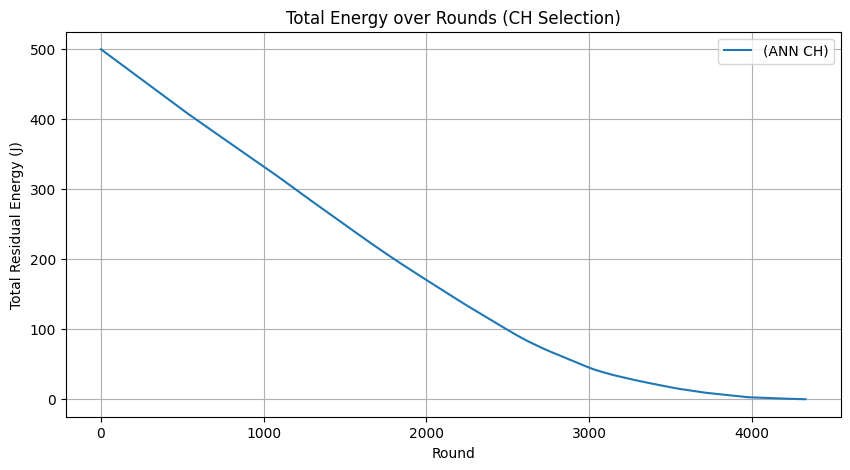

In [ ]:
# ee_mac_with_ANN_ch_selection
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection, 4,3 will create total 12 region
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================
# Helper functions
# ================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    # clamp to valid region indices
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# ================================
# Create synthetic dataset & train
# ================================
def make_training_dataset(num_samples=2000, grid_size=GRID_SIZE, seed=32):
    np.random.seed(seed)
    xs = np.random.uniform(0, grid_size, num_samples)
    ys = np.random.uniform(0, grid_size, num_samples)
    energies = np.random.uniform(0.0, INITIAL_ENERGY, num_samples)
    event_counts = np.random.randint(0, 10, num_samples)
    base_x, base_y = base_station
    dist_to_bs = np.sqrt((xs-base_x)**2 + (ys-base_y)**2)

    # compute neighbors (approx) within COMM_RANGE
    neighbors = []
    coords = np.vstack([xs, ys]).T
    for i in range(num_samples):
        dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
        neighbors.append(np.sum(dists <= COMM_RANGE)-1)
    neighbors = np.array(neighbors)

    df = pd.DataFrame({
        "Residual_Energy": energies,
        "Event_Count": event_counts,
        "Distance_to_BS": dist_to_bs,
        "Number_of_Neighbors": neighbors
    })
    return df

def compute_target_score(df, alpha=0.7, beta=0.7):

    # Target = (alpha * RE + (1-alpha) * NBR) / (beta * DIST + (1-beta) * EVE)
    # stabilize denominator with small epsilon
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values

def train_ann(df_train, epochs=50, batch_size=32):
    X = df_train[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]].values
    y = compute_target_score(df_train)
    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.3, random_state=SEED)

    model = Sequential([
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, scaler

# Prepare and train ANN once before simulation
training_df = make_training_dataset(num_samples=2000, seed=SEED+1)    #why seed is plus 1
ann_model, ann_scaler = train_ann(training_df, epochs=100, batch_size=8)
print("ANN training complete.")

# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# event counts (EVE)
event_counts = np.random.randint(0, 10, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
neighbors_count = []
coords = np.vstack([x_positions, y_positions]).T
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# ==============================
# Set up phase with ANN CH
# ==============================
def run_eemac_ann_ch():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}


    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection using ANN + region partitioning ---
        # For each region, pick the eligible node (energy>TE) with maximum ANN-predicted score.
        # If a region has no eligible nodes, pick highest-residual-energy alive node within region.
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                # eligible nodes: RE > TE
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    # fallback: choose highest-energy alive node in region
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for ANN
                # Convert node_energy dictionary to array for easier indexing
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])

                X_feat = np.stack([
                    node_energy_arr[eligible],            # Residual_Energy (current)
                    event_counts[eligible],               # Event_Count (EVE)
                    distances_to_bs[eligible],            # Distance_to_BS
                    neighbors_count[eligible]             # Number_of_Neighbors
                ], axis=1)
                Xs = ann_scaler.transform(X_feat)
                scores = ann_model.predict(Xs, verbose=0).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)


        # If still no final CHs (very unlikely), pick global max-energy alive node
        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]


        # --- CHs broadcast ADV ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For non-CH alive nodes: receive ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # --- Join Requests and ACK logic  ---
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag.get(node, False):
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast (conservative radius)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                 x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes try next CH
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast: CHs announce schedules
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # Data (steady-state) phase

        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # fallback nodes send directly to BS
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False)]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_ann_ch()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" CH selection: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded (unexpected).")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='ANN CH)')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ( ANN CH Selection)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='(ANN CH)')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (CH Selection)")
plt.grid(True)
plt.legend()
plt.show()


Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 99
Round 1700: Alive 99
Round 1800: Alive 99
Round 1900: Alive 99
Round 2000: Alive 98
Round 2100: Alive 98
Round 2200: Alive 96
Round 2300: Alive 95
Round 2400: Alive 87
Round 2500: Alive 85
Round 2600: Alive 80
Round 2700: Alive 78
Round 2800: Alive 69
Round 2900: Alive 59
Round 3000: Alive 52
Round 3100: Alive 42
Round 3200: Alive 34
Round 3300: Alive 19
Round 3400: Alive 17
Round 3500: Alive 11
Round 3600: Alive 11
Round 3700: Alive 8
Round 3800: Alive 8
Round 3900: Alive 8
Round 4000: Alive 8
 CH selection: FND = 1548 LND = 4031


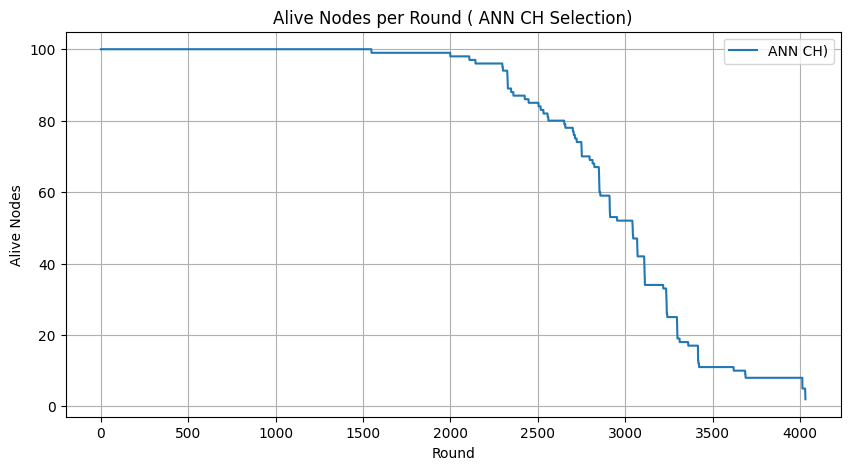

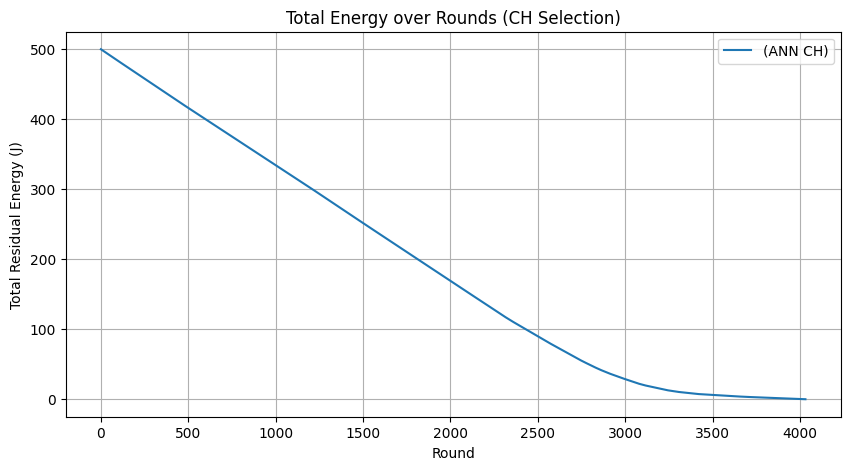

In [ ]:
# ee_mac_without_ANN_ch_selection (works almost same as ANN)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection, 4,3 will create total 12 region
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

SEED = 42
np.random.seed(SEED)


# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================
# Helper functions
# ================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    # clamp to valid region indices
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)



def compute_target_score(df, alpha=0.7, beta=0.7):

    # Target = (alpha * RE + (1-alpha) * NBR) / (beta * DIST + (1-beta) * EVE)
    # stabilize denominator with small epsilon
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values



# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# event counts (EVE)
event_counts = np.random.randint(0, 10, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
neighbors_count = []
coords = np.vstack([x_positions, y_positions]).T
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# ==============================
# Set up phase CH
# ==============================
def run_eemac_ann_ch():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}


    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection using equation  + region partitioning ---
        # For each region, pick the eligible node (energy>TE) with maximum score.
        # If a region has no eligible nodes, pick highest-residual-energy alive node within region.
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                # eligible nodes: RE > TE
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    # fallback: choose highest-energy alive node in region
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for score calculation
                # Convert node_energy dictionary to array for easier indexing
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])

                X_feat = pd.DataFrame({
                    "Residual_Energy": node_energy_arr[eligible],            # Residual_Energy (current)
                    "Event_Count": event_counts[eligible],               # Event_Count (EVE)
                    "Distance_to_BS": distances_to_bs[eligible],            # Distance_to_BS
                    "Number_of_Neighbors": neighbors_count[eligible]            # Number_of_Neighbors
                })

                scores = compute_target_score(X_feat).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)


        # If still no final CHs (very unlikely), pick global max-energy alive node
        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]


        # --- CHs broadcast ADV ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For non-CH alive nodes: receive ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # --- Join Requests and ACK logic  ---
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag.get(node, False):
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast (conservative radius)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                 x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes try next CH
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast: CHs announce schedules
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # Data (steady-state) phase

        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # fallback nodes send directly to BS
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False)]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_ann_ch()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" CH selection: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded (unexpected).")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='ANN CH)')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ( ANN CH Selection)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='(ANN CH)')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (CH Selection)")
plt.grid(True)
plt.legend()
plt.show()


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20.5317 - mae: 2.1432 - val_loss: 7.0881 - val_mae: 1.3068
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.3488 - mae: 1.4342 - val_loss: 5.6231 - val_mae: 1.1039
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.6183 - mae: 1.1720 - val_loss: 4.7966 - val_mae: 0.9727
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.6144 - mae: 1.0904 - val_loss: 4.4022 - val_mae: 0.9848
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.0576 - mae: 1.1005 - val_loss: 4.0859 - val_mae: 0.9417
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.5824 - mae: 1.0478 - val_loss: 3.7118 - val_mae: 0.8423
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.0387 - mae: 0.9176 - val_loss: 3.2850 - val_mae: 0.6882
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10.4598 - mae: 0.7648 - val_loss: 2.8668 - val_mae: 0.5441
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

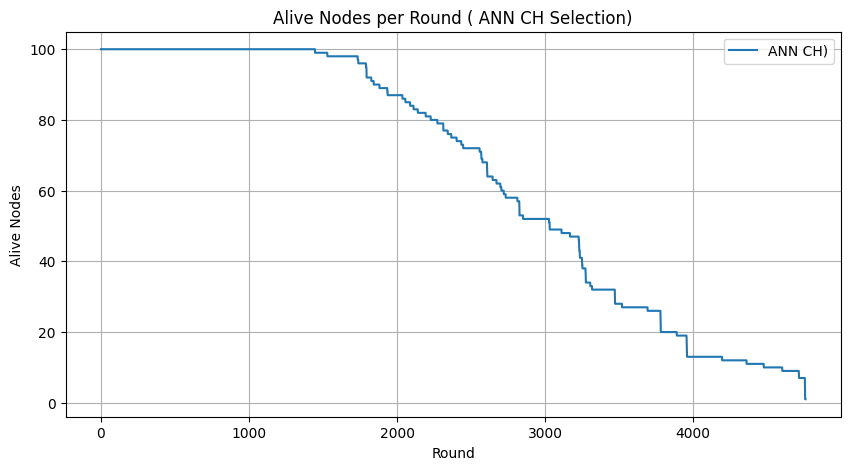

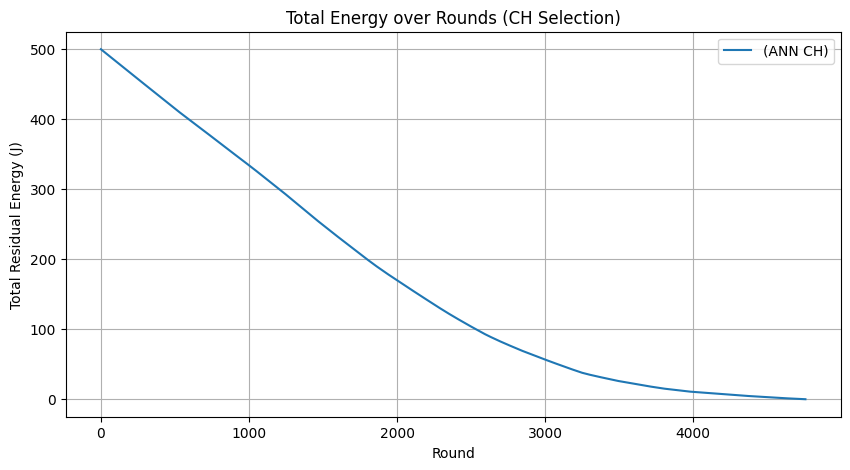

In [ ]:
# ee_mac_with_ANN_ch_selection (Distance Aware)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection, 4,3 will create total 12 region
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================
# Helper functions
# ================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    # clamp to valid region indices
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# ================================
# Create synthetic dataset & train
# ================================
def make_training_dataset(num_samples=2000, grid_size=GRID_SIZE, seed=32):
    np.random.seed(seed)
    xs = np.random.uniform(0, grid_size, num_samples)
    ys = np.random.uniform(0, grid_size, num_samples)
    energies = np.random.uniform(0.0, INITIAL_ENERGY, num_samples)
    event_counts = np.random.randint(0, 10, num_samples)
    base_x, base_y = base_station
    dist_to_bs = np.sqrt((xs-base_x)**2 + (ys-base_y)**2)

    # compute neighbors (approx) within COMM_RANGE
    neighbors = []
    coords = np.vstack([xs, ys]).T
    for i in range(num_samples):
        dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
        neighbors.append(np.sum(dists <= COMM_RANGE)-1)
    neighbors = np.array(neighbors)

    df = pd.DataFrame({
        "Residual_Energy": energies,
        "Event_Count": event_counts,
        "Distance_to_BS": dist_to_bs,
        "Number_of_Neighbors": neighbors
    })
    return df

def compute_target_score(df, alpha=0.7, beta=0.7):

    # Target = (alpha * RE + (1-alpha) * NBR) / (beta * DIST + (1-beta) * EVE)
    # stabilize denominator with small epsilon
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values

def train_ann(df_train, epochs=50, batch_size=32):
    X = df_train[["Residual_Energy", "Event_Count", "Distance_to_BS", "Number_of_Neighbors"]].values
    y = compute_target_score(df_train)
    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(X)
    X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.3, random_state=SEED)

    model = Sequential([
        Dense(8, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(1, activation="linear")
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, scaler

# Prepare and train ANN once before simulation
training_df = make_training_dataset(num_samples=2000, seed=SEED+1)
ann_model, ann_scaler = train_ann(training_df, epochs=100, batch_size=8)
print("ANN training complete.")

# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# event counts (EVE)
event_counts = np.random.randint(0, 10, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
neighbors_count = []
coords = np.vstack([x_positions, y_positions]).T
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# ==============================
# Set up phase with ANN CH
# ==============================
def run_eemac_ann_ch():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}


    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection using ANN + region partitioning ---
        # For each region, pick the eligible node (energy>TE) with maximum ANN-predicted score.
        # If a region has no eligible nodes, pick highest-residual-energy alive node within region.
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                # eligible nodes: RE > TE
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    # fallback: choose highest-energy alive node in region
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for ANN
                # Convert node_energy dictionary to array for easier indexing
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])

                X_feat = np.stack([
                    node_energy_arr[eligible],            # Residual_Energy (current)
                    event_counts[eligible],               # Event_Count (EVE)
                    distances_to_bs[eligible],            # Distance_to_BS
                    neighbors_count[eligible]             # Number_of_Neighbors
                ], axis=1)
                Xs = ann_scaler.transform(X_feat)
                scores = ann_model.predict(Xs, verbose=0).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)


        # If still no final CHs (very unlikely), pick global max-energy alive node
        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]


        # --- CHs broadcast ADV ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For non-CH alive nodes: receive ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    # Node decides BS is closer → skip join requests
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False  # mark as fallback
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests and ACK logic  ---
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast (conservative radius)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                 x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes try next CH
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast: CHs announce schedules
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # Data (steady-state) phase

        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # fallback nodes send directly to BS
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_ann_ch()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" CH selection: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded (unexpected).")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='ANN CH)')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ( ANN CH Selection)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='(ANN CH)')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (CH Selection)")
plt.grid(True)
plt.legend()
plt.show()


Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 99
Round 1700: Alive 99
Round 1800: Alive 99
Round 1900: Alive 99
Round 2000: Alive 99
Round 2100: Alive 98
Round 2200: Alive 96
Round 2300: Alive 95
Round 2400: Alive 88
Round 2500: Alive 86
Round 2600: Alive 81
Round 2700: Alive 77
Round 2800: Alive 71
Round 2900: Alive 60
Round 3000: Alive 54
Round 3100: Alive 44
Round 3200: Alive 36
Round 3300: Alive 27
Round 3400: Alive 18
Round 3500: Alive 12
Round 3600: Alive 12
Round 3700: Alive 12
Round 3800: Alive 12
Round 3900: Alive 11
Round 4000: Alive 10
Round 4100: Alive 10
Round 4200: Alive 10
Round 4300: Alive 5
Round 4400: Alive 4
Round 4500: Alive 4
Round 4600: Alive 3
Round 4700: Alive 3
 CH selectio

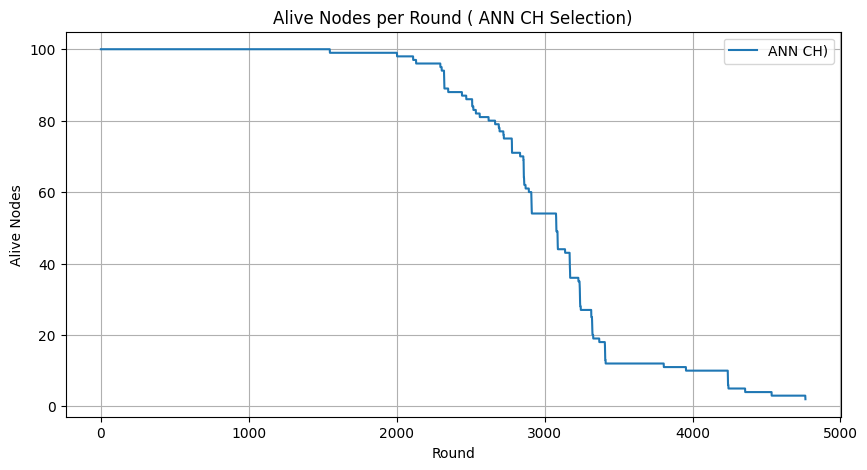

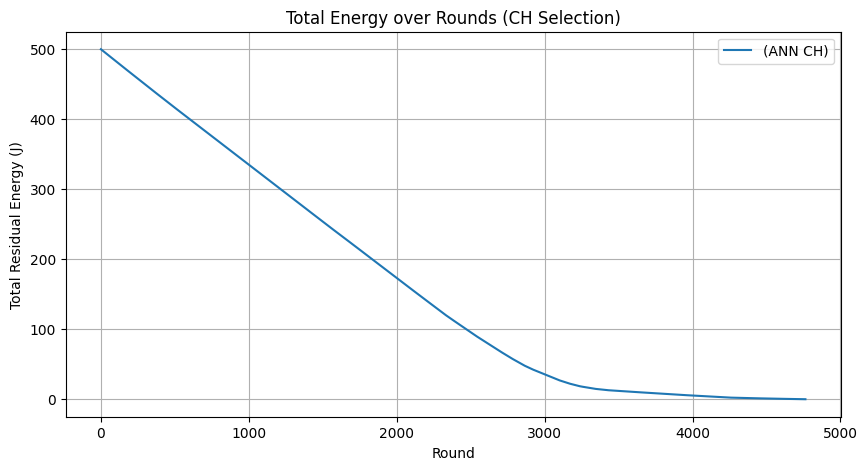

In [ ]:
# ee_mac_without_ANN_ch_selection (distance aware)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection, 4,3 will create total 12 region
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================
# Helper functions
# ================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    # clamp to valid region indices
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)



def compute_target_score(df, alpha=0.7, beta=0.7):

    # Target = (alpha * RE + (1-alpha) * NBR) / (beta * DIST + (1-beta) * EVE)
    # stabilize denominator with small epsilon
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values



# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# event counts (EVE)
event_counts = np.random.randint(0, 10, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
neighbors_count = []
coords = np.vstack([x_positions, y_positions]).T
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# ==============================
# Set up phase CH
# ==============================
def run_eemac_ann_ch():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}


    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection using equation  + region partitioning ---
        # For each region, pick the eligible node (energy>TE) with maximum score.
        # If a region has no eligible nodes, pick highest-residual-energy alive node within region.
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                # eligible nodes: RE > TE
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    # fallback: choose highest-energy alive node in region
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for score calculation
                # Convert node_energy dictionary to array for easier indexing
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])

                X_feat = pd.DataFrame({
                    "Residual_Energy": node_energy_arr[eligible],            # Residual_Energy (current)
                    "Event_Count": event_counts[eligible],               # Event_Count (EVE)
                    "Distance_to_BS": distances_to_bs[eligible],            # Distance_to_BS
                    "Number_of_Neighbors": neighbors_count[eligible]            # Number_of_Neighbors
                })

                scores = compute_target_score(X_feat).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)


        # If still no final CHs (very unlikely), pick global max-energy alive node
        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]


        # --- CHs broadcast ADV ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For non-CH alive nodes: receive ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    # Node decides BS is closer → skip join requests
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False  # mark as fallback
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests and ACK logic  ---
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast (conservative radius)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                 x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes try next CH
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast: CHs announce schedules
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # Data (steady-state) phase

        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # fallback nodes send directly to BS
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_ann_ch()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" CH selection: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded (unexpected).")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='ANN CH)')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ( ANN CH Selection)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='(ANN CH)')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (CH Selection)")
plt.grid(True)
plt.legend()
plt.show()



Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 98
Round 1500: Alive 97
Round 1600: Alive 97
Round 1700: Alive 94
Round 1800: Alive 93
Round 1900: Alive 92
Round 2000: Alive 89
Round 2100: Alive 82
Round 2200: Alive 76
Round 2300: Alive 69
Round 2400: Alive 63
Round 2500: Alive 51
Round 2600: Alive 39
Round 2700: Alive 36
Round 2800: Alive 27
Round 2900: Alive 18
Round 3000: Alive 14
Round 3100: Alive 12
Round 3200: Alive 12
Round 3300: Alive 12
Round 3400: Alive 11
Round 3500: Alive 11
Round 3600: Alive 10
Round 3700: Alive 10
Round 3800: Alive 10
Round 3900: Alive 10
Round 4000: Alive 7
Round 4100: Alive 3
Round 4200: Alive 2
 CH selection: FND = 1334 LND = 4229


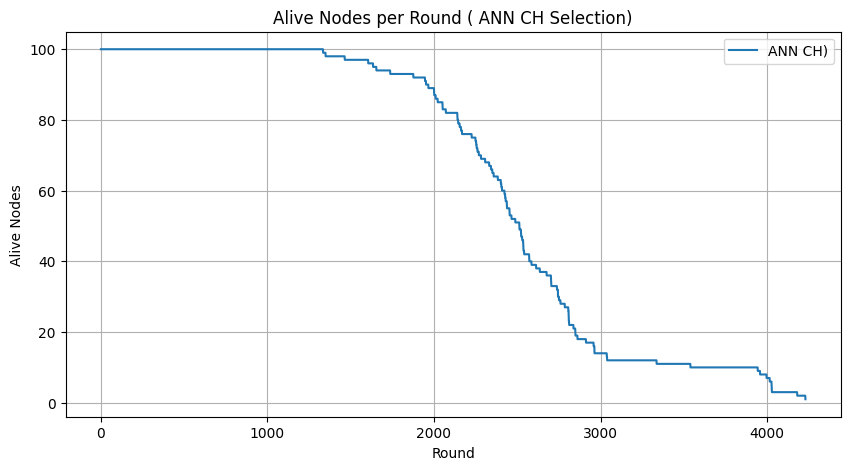

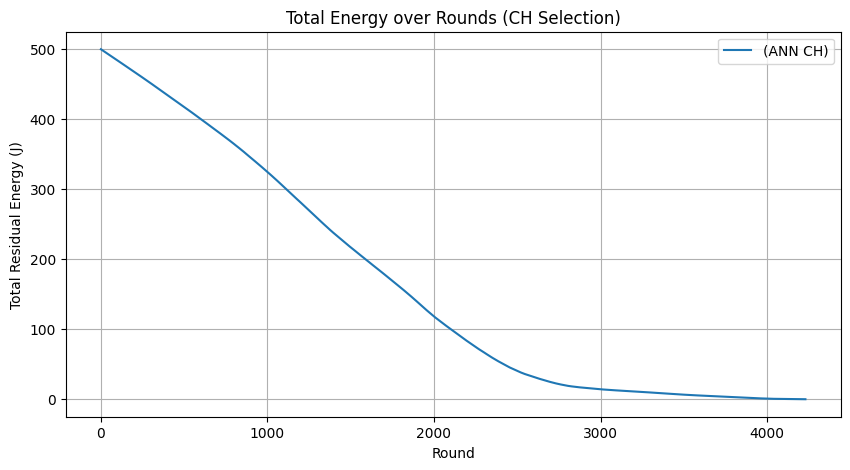

In [ ]:
# ee_mac_without_ANN_ch_selection (distance aware)(adaptive MCS)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection, 4,3 will create total 12 region
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================
# Helper functions
# ================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    # clamp to valid region indices
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)



def compute_target_score(df, alpha=0.7, beta=0.7):

    # Target = (alpha * RE + (1-alpha) * NBR) / (beta * DIST + (1-beta) * EVE)
    # stabilize denominator with small epsilon
    num = (alpha * df["Residual_Energy"] + (1 - alpha) * df["Number_of_Neighbors"])
    den = (beta * df["Distance_to_BS"] + (1 - beta) * df["Event_Count"])
    return (num / den).values

# --- C. adaptive MCS per CH (when accepting join requests) ---
def compute_MCS_for_ch(ch, node_energy):
    scale = 1.5
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap



# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# event counts (EVE)
event_counts = np.random.randint(0, 10, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
neighbors_count = []
coords = np.vstack([x_positions, y_positions]).T
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y

# ==============================
# Set up phase CH
# ==============================
def run_eemac_ann_ch():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}


    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection using equation  + region partitioning ---
        # For each region, pick the eligible node (energy>TE) with maximum score.
        # If a region has no eligible nodes, pick highest-residual-energy alive node within region.
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                # eligible nodes: RE > TE
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    # fallback: choose highest-energy alive node in region
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # prepare features for score calculation
                # Convert node_energy dictionary to array for easier indexing
                node_energy_arr = np.array([node_energy[i] for i in range(NUM_NODES)])

                X_feat = pd.DataFrame({
                    "Residual_Energy": node_energy_arr[eligible],            # Residual_Energy (current)
                    "Event_Count": event_counts[eligible],               # Event_Count (EVE)
                    "Distance_to_BS": distances_to_bs[eligible],            # Distance_to_BS
                    "Number_of_Neighbors": neighbors_count[eligible]            # Number_of_Neighbors
                })

                scores = compute_target_score(X_feat).flatten()
                best_idx = np.argmax(scores)
                best_node = eligible[best_idx]
                final_chs.append(best_node)


        # If still no final CHs (very unlikely), pick global max-energy alive node
        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]


        # --- CHs broadcast ADV ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For non-CH alive nodes: receive ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    # Node decides BS is closer → skip join requests
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False  # mark as fallback
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests and ACK logic  ---
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast (conservative radius)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                 x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes try next CH
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast: CHs announce schedules
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # Data (steady-state) phase

        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # fallback nodes send directly to BS
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_ann_ch()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" CH selection: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded (unexpected).")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='ANN CH)')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ( ANN CH Selection)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='(ANN CH)')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (CH Selection)")
plt.grid(True)
plt.legend()
plt.show()



Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 100
Round 1700: Alive 100
Round 1800: Alive 100
Round 1900: Alive 100
Round 2000: Alive 100
Round 2100: Alive 100
Round 2200: Alive 100
Round 2300: Alive 100
Round 2400: Alive 98
Round 2500: Alive 90
Round 2600: Alive 83
Round 2700: Alive 82
Round 2800: Alive 72
Round 2900: Alive 53
Round 3000: Alive 32
Round 3100: Alive 20
Round 3200: Alive 14
Round 3300: Alive 13
Round 3400: Alive 13
Round 3500: Alive 13
Round 3600: Alive 13
Round 3700: Alive 12
Round 3800: Alive 12
Round 3900: Alive 5
Round 4000: Alive 5
Round 4100: Alive 5
Round 4200: Alive 4
Round 4300: Alive 3
Round 4400: Alive 3
Round 4500: Alive 3
Round 4600: Alive 3
 CH selection: FND = 2352 LN

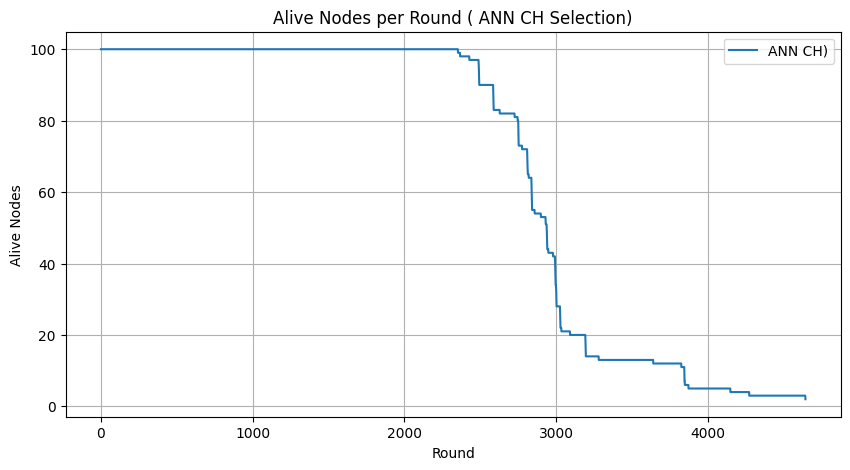

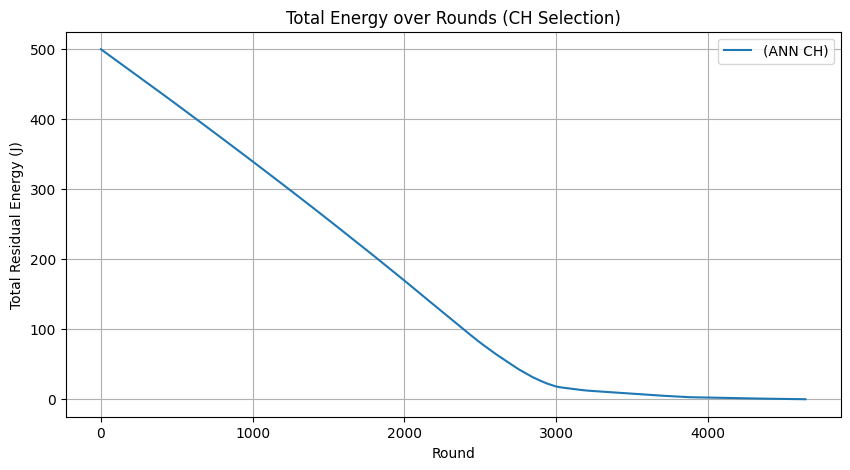

In [ ]:
# ee_mac_without_ANN_ch_selection (distance aware)(remove EVE feature and add distance to region centre DRC feature )
# adaptive MCS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10              # max cluster size
COMM_RANGE = 20       # neighbor definition for dataset / ANN
NUM_REGIONS_X = 4     # grid regions for CH selection, 4,3 will create total 12 region
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ================
# Helper functions
# ================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    # clamp to valid region indices
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# --- C. adaptive MCS per CH (when accepting join requests) ---
def compute_MCS_for_ch(ch, node_energy):
    scale = 1.5
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap

# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)



# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
neighbors_count = []
coords = np.vstack([x_positions, y_positions]).T
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y


# Precompute region centers
region_centers = {}
for rx in range(NUM_REGIONS_X):
    for ry in range(NUM_REGIONS_Y):
        cx = (rx + 0.5) * region_w
        cy = (ry + 0.5) * region_h
        region_centers[(rx, ry)] = (cx, cy)

# normalizers
D_MAX = math.sqrt(2) * GRID_SIZE                     # max distance in grid (corner to corner)
REGION_DIAG = math.sqrt(region_w**2 + region_h**2)
R_MAX = REGION_DIAG / 2.0                             # approx max distance to region center
NBR_MAX = max(1, int(np.max(neighbors_count)))        # avoid zero; or set upper bound e.g. area density


# weights
ALPHA = 0.7
BETA  = 0.6

def compute_drc_for_node(n):
    rx, ry = assign_region(x_positions[n], y_positions[n], region_w, region_h)
    cx, cy = region_centers[(rx, ry)]
    return calculate_distance(x_positions[n], y_positions[n], cx, cy)

def compute_score_node(n, node_energy):
    RE = node_energy[n]
    NBR = neighbors_count[n]
    Dbs = distances_to_bs[n]
    Drc = compute_drc_for_node(n)

    # normalize
    RE_n = RE / INITIAL_ENERGY
    NBR_n = NBR / float(NBR_MAX)
    Dbs_n = Dbs / D_MAX
    Drc_n = Drc / R_MAX

    num = ALPHA * RE_n + (1.0 - ALPHA) * NBR_n
    den = BETA * Dbs_n + (1.0 - BETA) * Drc_n
    return num / den


# ==============================
# Set up phase CH
# ==============================
def run_eemac_ann_ch():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}


    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection using equation  + region partitioning ---
        # For each region, pick the eligible node (energy>TE) with maximum score.
        # If a region has no eligible nodes, pick highest-residual-energy alive node within region.
        region_nodes = {}  # region -> list of node indices (alive)
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                # eligible nodes: RE > TE
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    # fallback: choose highest-energy alive node in region
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue

                # score calculation using equation
                scores = [compute_score_node(n, node_energy) for n in eligible]
                best_node = eligible[int(np.argmax(scores))]
                final_chs.append(best_node)


        # If still no final CHs (very unlikely), pick global max-energy alive node
        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]


        # --- CHs broadcast ADV ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # For non-CH alive nodes: receive ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num


        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    # Node decides BS is closer → skip join requests
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False  # mark as fallback
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests and ACK logic  ---
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(5, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast (conservative radius)
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                 x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes try next CH
                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast: CHs announce schedules
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # Data (steady-state) phase

        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # fallback nodes send directly to BS
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_ann_ch()

# Only consider nodes that actually died
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" CH selection: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded (unexpected).")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='ANN CH)')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ( ANN CH Selection)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='(ANN CH)')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (CH Selection)")
plt.grid(True)
plt.legend()
plt.show()



When a CH decides to send to BS:

Check if BS is farther than DIST_THRESHOLD.

If yes → try relay selection.

Relay selection function:

Iterate over all other CHs.

Skip if relay candidate is dead.

Compute Score_r using above formula.

Pick the relay with maximum score.

Update energy consumption:

CH → Relay: transmission cost.

Relay → BS: transmission + aggregation cost.

Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 100
Round 1700: Alive 100
Round 1800: Alive 100
Round 1900: Alive 100
Round 2000: Alive 100
Round 2100: Alive 100
Round 2200: Alive 98
Round 2300: Alive 98
Round 2400: Alive 98
Round 2500: Alive 96
Round 2600: Alive 83
Round 2700: Alive 79
Round 2800: Alive 68
Round 2900: Alive 52
Round 3000: Alive 35
Round 3100: Alive 21
Round 3200: Alive 13
Round 3300: Alive 13
Round 3400: Alive 13
Round 3500: Alive 12
Round 3600: Alive 12
Round 3700: Alive 5
Round 3800: Alive 5
Round 3900: Alive 5
Round 4000: Alive 3
Round 4100: Alive 3
Round 4200: Alive 3
 FND = 2123 LND = 4280


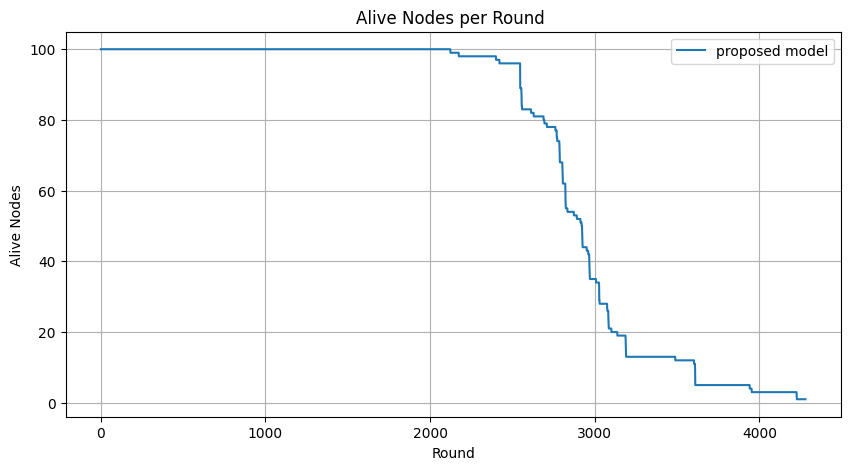

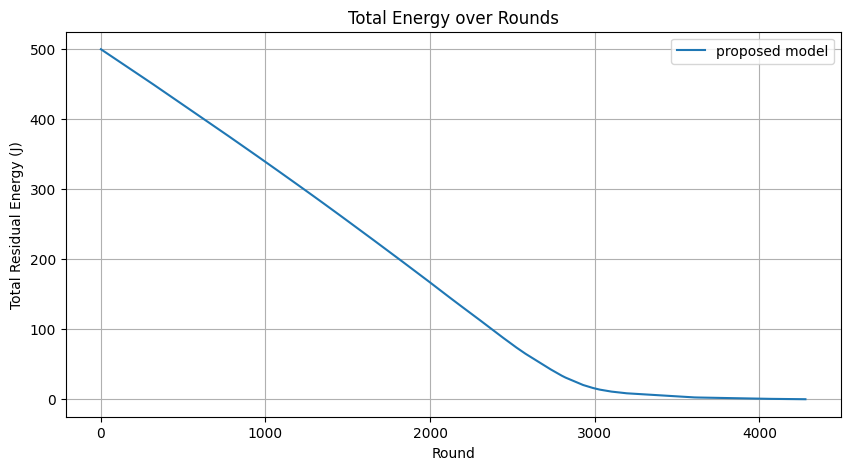

In [ ]:
# ee_mac_without_ANN_ch_selection (distance aware)(remove EVE feature and add distance to region centre DRC feature ) (adaptive MCS)(Double-hop not Multi-hop )
#Intra-cluster Multi-Hop (Node → Relay → CH)
#Each node checks if sending directly to CH costs more energy than sending to a closer neighbor.
#If yes, it forwards via the relay (lowest total energy path).
#Inter-cluster Multi-Hop (CH → Relay CH → … → BS)
#Each CH decides whether to transmit directly to BS or forward via another CH that is closer to BS.
#Similar to LEACH-MH (multi-hop LEACH), but integrated into your ANN+distance aware model.
import numpy as np
import matplotlib.pyplot as plt
import math

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10            # max cluster size (per CH)
COMM_RANGE = 20     # neighbor definition
NUM_REGIONS_X = 4   # grid regions for CH selection
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes (bits)
K_DATA = 100 * 8
K_CTRL = 20 * 8

RELAY_THRESHOLD = 0.1 * INITIAL_ENERGY   # only consider relays with ≥10% energy


# Seed
SEED = 42
np.random.seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ==============================
# Helper functions
# ==============================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# . adaptive MCS per CH (when accepting join requests) ---
def compute_MCS_for_ch(ch, node_energy):
    scale = 1.5
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap

# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
coords = np.vstack([x_positions, y_positions]).T
neighbors_count = []
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes and centers
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y
region_centers = {}
for rx in range(NUM_REGIONS_X):
    for ry in range(NUM_REGIONS_Y):
        cx = (rx + 0.5) * region_w
        cy = (ry + 0.5) * region_h
        region_centers[(rx, ry)] = (cx, cy)

# normalizers & weights for DRC scoring
D_MAX = math.sqrt(2) * GRID_SIZE
REGION_DIAG = math.sqrt(region_w**2 + region_h**2)
R_MAX = REGION_DIAG / 2.0
NBR_MAX = max(1, int(np.max(neighbors_count)))
ALPHA = 0.7
BETA  = 0.6


def compute_drc_for_node(n):
    rx, ry = assign_region(x_positions[n], y_positions[n], region_w, region_h)
    cx, cy = region_centers[(rx, ry)]
    return calculate_distance(x_positions[n], y_positions[n], cx, cy)

def compute_score_node(n, node_energy):
    RE = node_energy[n]
    NBR = neighbors_count[n]
    Dbs = distances_to_bs[n]
    Drc = compute_drc_for_node(n)
    RE_n = RE / INITIAL_ENERGY
    NBR_n = NBR / float(NBR_MAX)
    Dbs_n = Dbs / D_MAX
    Drc_n = Drc / R_MAX
    num = ALPHA * RE_n + (1.0 - ALPHA) * NBR_n
    den = BETA * Dbs_n + (1.0 - BETA) * Drc_n
    return num / den

def broadcast_radius_for_ch(ch, members):
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# -------------------------
# Relay selection metric for CH -> relay CH -> BS
# -------------------------
# weights for relay selection score (sum not required to be 1)
RELAY_ALPHA = 0.5   # weight for relay residual energy
RELAY_BETA  = 0.3   # weight for closeness to source CH (prefer closer)
RELAY_GAMMA = 0.2   # weight for closeness to BS (prefer closer to BS)

def select_relay_ch(ch, ch_list, node_energy):
    """Select the best CH relay for 'ch' from ch_list (other CHs).
       Returns relay index and tuple(d_ch_relay, d_relay_bs) or (None, (None,None))."""
    best_score = -1.0
    best_relay = None
    best_d1 = None
    best_d2 = None
    for r in ch_list:
        if r == ch:
            continue
        if node_energy.get(r, 0) <= 0:
            continue
        d_cr = calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[r], y_positions[r])
        d_rb = calculate_distance(x_positions[r], y_positions[r],
                                  base_station[0], base_station[1])
        # Avoid division by zero; prefer nearer relays and relays with more energy
        score = (RELAY_ALPHA * (node_energy[r] / INITIAL_ENERGY) +
                 RELAY_BETA * (1.0 / (d_cr + 1e-6)) +
                 RELAY_GAMMA * (1.0 / (d_rb + 1e-6)))
        if score > best_score:
            best_score = score
            best_relay = r
            best_d1 = d_cr
            best_d2 = d_rb
    return best_relay, (best_d1, best_d2)

# ==============================
# Main simulation loop (with relay metric)
# ==============================
def run_eemac_drc_multihop_with_relay():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # -------------------------
        # CH selection per region (DRC-based score)
        # -------------------------
        region_nodes = {}
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue
                scores = [compute_score_node(n, node_energy) for n in eligible]
                best_node = eligible[int(np.argmax(scores))]
                final_chs.append(best_node)

        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]

        # Precompute assigned structures
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # -------------------------
        # ADV broadcast (CH -> all)
        # -------------------------
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            d_adv = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                           x_positions[n], y_positions[n]) for n in other_nodes)
                     if other_nodes else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs: continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # -------------------------
        # Distance-aware cluster participation (fallback if BS closer)
        # -------------------------
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs: continue
            d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(((calculate_distance(x_positions[n], y_positions[n],
                                                    x_positions[ch], y_positions[ch]), ch)
                               for ch in final_chs), key=lambda x: x[0])
                if d_bs < d_ch:
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # -------------------------
        # Join requests & ACKs
        # -------------------------
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag.get(node, False) or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch])) for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num
                if num_requests == 0: continue

                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(5, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                  x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # -------------------------
        # TDMA schedule broadcast
        # -------------------------
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num
            for n in assigned[ch]:
                if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # -------------------------
        # Steady-state: Data phase with Intra + Inter multi-hop (relay metric)
        # -------------------------
        for session in range(M_SESSIONS):
            ch_received_counts = {ch: 0 for ch in final_chs}

            # INTRA-CLUSTER MULTI-HOP (member -> relay member -> CH)
            for ch in final_chs:
                for n in assigned[ch]:
                    if node_energy[n] <= 0: continue
                    if np.random.random() >= P_DATA_SESSION: continue

                    d_direct = calculate_distance(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch])
                    E_direct = energy_tx(K_DATA, d_direct)

                    best_cost = E_direct
                    best_relay = None
                    best_d1 = None
                    best_d2 = None
                    for r in assigned[ch]:
                        if r == n or node_energy[r] <= 0: continue
                        d1 = calculate_distance(x_positions[n], y_positions[n], x_positions[r], y_positions[r])
                        d2 = calculate_distance(x_positions[r], y_positions[r], x_positions[ch], y_positions[ch])
                        cost = energy_tx(K_DATA, d1) + energy_tx(K_DATA, d2)
                        if cost < best_cost:
                            best_cost = cost
                            best_relay = r
                            best_d1 = d1
                            best_d2 = d2

                    if best_relay is None:
                        # direct member -> CH
                        node_energy[n] -= E_direct
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                        else:
                            ch_received_counts[ch] += 1
                    else:
                        # node -> relay
                        node_energy[n] -= energy_tx(K_DATA, best_d1)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        # relay receives
                        node_energy[best_relay] -= energy_rx(K_DATA)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                            continue
                        # relay forwards to CH
                        node_energy[best_relay] -= energy_tx(K_DATA, best_d2)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                        else:
                            ch_received_counts[ch] += 1

            # INTER-CLUSTER MULTI-HOP (CH -> relay CH -> BS) using relay metric
            for ch in final_chs:
                num_recv = ch_received_counts.get(ch, 0)
                if num_recv == 0:
                    continue

                E_rx = num_recv * energy_rx(K_DATA)
                E_agg = num_recv * energy_da(K_DATA)
                d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_bs)

                # select best relay using metric
                relay, (d_cr, d_rb) = select_relay_ch(ch, final_chs, node_energy)
                # only use relay if found and it reduces energy compared to direct
                if relay is not None and d_cr is not None and d_rb is not None:
                    cost_via = energy_tx(K_DATA, d_cr) + energy_tx(K_DATA, d_rb)
                else:
                    cost_via = float('inf')

                if cost_via < E_direct_bs and node_energy[relay] > RELAY_THRESHOLD:
                    # energy the relay must spend
                    E_relay_needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_rb)
                    if node_energy[relay] > E_relay_needed:
                      # relay path is feasible
                      node_energy[ch] -= (E_rx + E_agg + energy_tx(K_DATA, d_cr))
                      if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num
                      else:
                        # relay receives aggregated packet(s)
                        node_energy[relay] -= energy_rx(K_DATA)
                        if node_energy[relay] <= 0 and death_round[relay] is None:
                          death_round[relay] = round_num
                        else:
                          # relay forwards to BS
                          node_energy[relay] -= energy_tx(K_DATA, d_rb)
                          if node_energy[relay] <= 0 and death_round[relay] is None:
                            death_round[relay] = round_num
                    else:
                      # fallback: relay too weak → send direct to BS
                      node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                      if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num


                else:
                    # direct CH -> BS
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # FALLBACK nodes (not assigned) send direct to BS
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False) and n not in bs_closer_nodes]
            for n in fallback_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

            # bs_closer_nodes send direct to BS
            for n in bs_closer_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_drc_multihop_with_relay()

# compute FND / LND if available
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded.")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds")
plt.grid(True); plt.legend(); plt.show()


Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 100
Round 1700: Alive 100
Round 1800: Alive 100
Round 1900: Alive 100
Round 2000: Alive 100
Round 2100: Alive 100
Round 2200: Alive 98
Round 2300: Alive 98
Round 2400: Alive 97
Round 2500: Alive 96
Round 2600: Alive 89
Round 2700: Alive 79
Round 2800: Alive 62
Round 2900: Alive 46
Round 3000: Alive 34
Round 3100: Alive 23
Round 3200: Alive 14
Round 3300: Alive 13
Round 3400: Alive 13
Round 3500: Alive 6
Round 3600: Alive 6
Round 3700: Alive 6
Round 3800: Alive 5
Round 3900: Alive 5
Round 4000: Alive 5
Round 4100: Alive 4
Round 4200: Alive 3
Round 4300: Alive 3
Round 4400: Alive 3
DRC + True Multi-hop: FND = 2144 LND = 4497


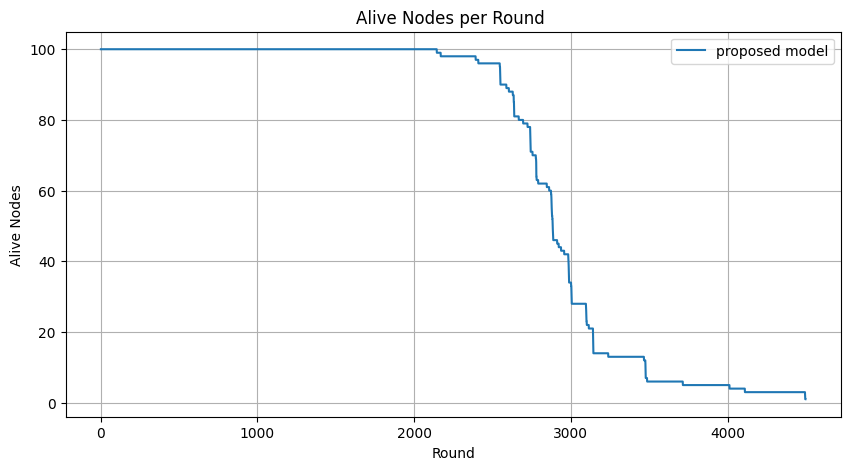

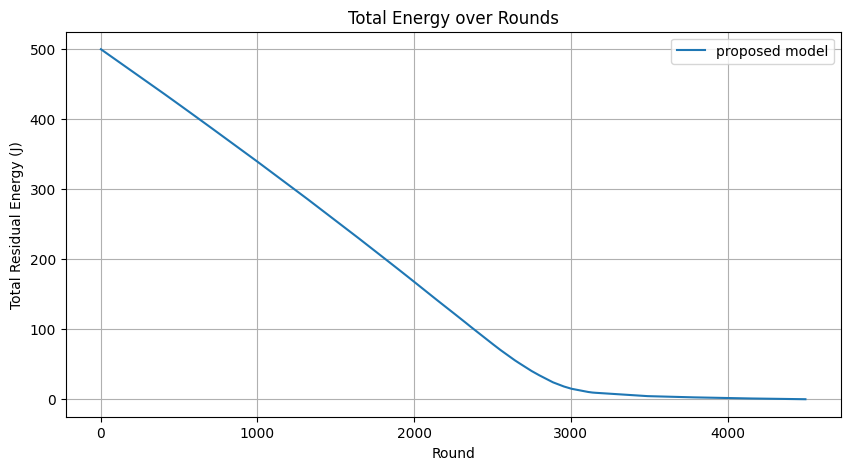

In [ ]:
# ee_mac_drc_true_multihop.py
import numpy as np
import matplotlib.pyplot as plt
import math
import heapq

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10            # max cluster size (per CH)
COMM_RANGE = 20     # neighbor definition
NUM_REGIONS_X = 4   # grid regions for CH selection
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes (bits)
K_DATA = 100 * 8
K_CTRL = 20 * 8

RELAY_THRESHOLD = 0.1 * INITIAL_ENERGY   # only consider relays with ≥10% energy

# Seed
SEED = 42
np.random.seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ==============================
# Helper functions
# ==============================
def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# adaptive MCS per CH (when accepting join requests)
def compute_MCS_for_ch(ch, node_energy):
    scale = 1.5
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap

# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
coords = np.vstack([x_positions, y_positions]).T
neighbors_count = []
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes and centers
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y
region_centers = {}
for rx in range(NUM_REGIONS_X):
    for ry in range(NUM_REGIONS_Y):
        cx = (rx + 0.5) * region_w
        cy = (ry + 0.5) * region_h
        region_centers[(rx, ry)] = (cx, cy)

# normalizers & weights for DRC scoring
D_MAX = math.sqrt(2) * GRID_SIZE
REGION_DIAG = math.sqrt(region_w**2 + region_h**2)
R_MAX = REGION_DIAG / 2.0
NBR_MAX = max(1, int(np.max(neighbors_count)))
ALPHA = 0.7
BETA  = 0.6

def compute_drc_for_node(n):
    rx, ry = assign_region(x_positions[n], y_positions[n], region_w, region_h)
    cx, cy = region_centers[(rx, ry)]
    return calculate_distance(x_positions[n], y_positions[n], cx, cy)

def compute_score_node(n, node_energy):
    RE = node_energy[n]
    NBR = neighbors_count[n]
    Dbs = distances_to_bs[n]
    Drc = compute_drc_for_node(n)
    RE_n = RE / INITIAL_ENERGY
    NBR_n = NBR / float(NBR_MAX)
    Dbs_n = Dbs / D_MAX
    Drc_n = Drc / R_MAX
    num = ALPHA * RE_n + (1.0 - ALPHA) * NBR_n
    den = BETA * Dbs_n + (1.0 - BETA) * Drc_n + 1e-12
    return num / den

def broadcast_radius_for_ch(ch, members):
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# -------------------------
# Relay selection metric for CH -> relay CH -> BS (NOT used for multi-hop path search)
# kept for potential fallback
RELAY_ALPHA = 0.5   # weight for relay residual energy
RELAY_BETA  = 0.3   # weight for closeness to source CH (prefer closer)
RELAY_GAMMA = 0.2   # weight for closeness to BS (prefer closer to BS)

def select_relay_ch(ch, ch_list, node_energy):
    """Greedy single-relay pick (kept if you need single-hop relay)."""
    best_score = -1.0
    best_relay = None
    best_d1 = None
    best_d2 = None
    for r in ch_list:
        if r == ch:
            continue
        if node_energy.get(r, 0) <= 0:
            continue
        d_cr = calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[r], y_positions[r])
        d_rb = calculate_distance(x_positions[r], y_positions[r],
                                  base_station[0], base_station[1])
        score = (RELAY_ALPHA * (node_energy[r] / INITIAL_ENERGY) +
                 RELAY_BETA * (1.0 / (d_cr + 1e-6)) +
                 RELAY_GAMMA * (1.0 / (d_rb + 1e-6)))
        if score > best_score:
            best_score = score
            best_relay = r
            best_d1 = d_cr
            best_d2 = d_rb
    return best_relay, (best_d1, best_d2)

# -------------------------
# True multi-hop path finder (Dijkstra-like)
# -------------------------
def find_multihop_path(source_ch, ch_list, node_energy):
    """
    Find a feasible multi-hop path from source_ch to BS using CHs in ch_list.
    Returns (path, total_cost) where path is list [ch, next_ch, ...,] and final hop to BS implicit.
    If no feasible path, return (None, inf).
    The path does NOT include BS; last hop is from path[-1] to BS.
    """
    # Precompute distances to BS for CHs
    d_to_bs = {ch: calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]) for ch in ch_list}
    # Dijkstra over CH nodes; cost definition: sum(tx for each hop) + sum(rx at each intermediate)
    # We'll represent state as (cost_so_far, current_node, path_list)
    visited = set()
    pq = []
    # start from source_ch with cost 0 (we'll add source tx when we decide next hop)
    heapq.heappush(pq, (0.0, source_ch, [source_ch]))

    best_cost_to_bs = float('inf')
    best_path = None

    while pq:
        cost, u, path = heapq.heappop(pq)
        if (u, tuple(path)) in visited:
            continue
        visited.add((u, tuple(path)))

        # Option: go directly from u to BS (finish)
        d_u_bs = calculate_distance(x_positions[u], y_positions[u], base_station[0], base_station[1])
        cost_direct = cost + energy_tx(K_DATA, d_u_bs)
        # Before accepting direct, ensure u (the sender) can pay tx; the sender will be charged later
        if cost_direct < best_cost_to_bs:
            # Feasibility: intermediates in path must have sufficient energy to receive+forward
            feasible = True
            # For each intermediate node v in path[1:] (excluding original source), check it can do: E_rx + min_tx_to_bs
            for v in path[1:]:
                # estimate minimal forward cost from v: if it forwards directly to BS minimal tx is energy_tx(d_v_bs)
                min_forward = energy_tx(K_DATA, d_to_bs[v])
                if node_energy.get(v, 0) <= (energy_rx(K_DATA) + min_forward + RELAY_THRESHOLD*0.0):
                    feasible = False
                    break
            if feasible:
                best_cost_to_bs = cost_direct
                best_path = list(path)
        # Expand to other CH neighbors (avoid loops)
        for v in ch_list:
            if v == u or v in path:
                continue
            # require candidate relay v has at least RELAY_THRESHOLD
            if node_energy.get(v, 0) <= RELAY_THRESHOLD:
                continue
            d_uv = calculate_distance(x_positions[u], y_positions[u], x_positions[v], y_positions[v])
            # incremental cost: u transmits to v (u pays tx), v receives (we add rx here to reflect energy consumed), total add:
            add_cost = energy_tx(K_DATA, d_uv) + energy_rx(K_DATA)
            # feasibility check for v: it must be able to forward after receiving (at least direct to BS)
            d_v_bs = d_to_bs[v]
            min_forward = energy_tx(K_DATA, d_v_bs)
            if node_energy.get(v, 0) <= (energy_rx(K_DATA) + min_forward):
                # v cannot realistically forward after receiving
                continue
            new_cost = cost + add_cost
            # If this new_cost already exceeds best known direct cost, skip
            if new_cost >= best_cost_to_bs:
                continue
            new_path = path + [v]
            heapq.heappush(pq, (new_cost, v, new_path))

    if best_path is None:
        return None, float('inf')
    return best_path, best_cost_to_bs

# ==============================
# Main simulation loop (with true multi-hop inter-cluster)
# ==============================
def run_eemac_drc_true_multihop(max_rounds=10000, verbose=False):
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()) and round_num < max_rounds:
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if verbose and round_num % 100 == 0:
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # -------------------------
        # CH selection per region (DRC-based score)
        # -------------------------
        region_nodes = {}
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue
                scores = [compute_score_node(n, node_energy) for n in eligible]
                best_node = eligible[int(np.argmax(scores))]
                final_chs.append(best_node)

        if len(final_chs) == 0:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]

        # Precompute assigned structures
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # -------------------------
        # ADV broadcast (CH -> all)
        # -------------------------
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            d_adv = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                           x_positions[n], y_positions[n]) for n in other_nodes)
                     if other_nodes else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs: continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # -------------------------
        # Distance-aware cluster participation (fallback if BS closer)
        # -------------------------
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs: continue
            d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(((calculate_distance(x_positions[n], y_positions[n],
                                                    x_positions[ch], y_positions[ch]), ch)
                               for ch in final_chs), key=lambda x: x[0])
                if d_bs < d_ch:
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # -------------------------
        # Join requests & ACKs
        # -------------------------
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag.get(node, False) or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch])) for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num
                if num_requests == 0: continue

                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(5, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                  x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # -------------------------
        # TDMA schedule broadcast
        # -------------------------
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num
            for n in assigned[ch]:
                if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # -------------------------
        # Steady-state: Data phase with Intra + True multi-hop Inter-cluster
        # -------------------------
        for session in range(M_SESSIONS):
            ch_received_counts = {ch: 0 for ch in final_chs}

            # INTRA-CLUSTER MULTI-HOP (member -> relay member -> CH) (2-hop max)
            for ch in final_chs:
                for n in assigned[ch]:
                    if node_energy[n] <= 0: continue
                    if np.random.random() >= P_DATA_SESSION: continue

                    d_direct = calculate_distance(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch])
                    E_direct = energy_tx(K_DATA, d_direct)

                    best_cost = E_direct
                    best_relay = None
                    best_d1 = None
                    best_d2 = None
                    for r in assigned[ch]:
                        if r == n or node_energy[r] <= 0: continue
                        d1 = calculate_distance(x_positions[n], y_positions[n], x_positions[r], y_positions[r])
                        d2 = calculate_distance(x_positions[r], y_positions[r], x_positions[ch], y_positions[ch])
                        cost = energy_tx(K_DATA, d1) + energy_tx(K_DATA, d2)
                        if cost < best_cost:
                            best_cost = cost
                            best_relay = r
                            best_d1 = d1
                            best_d2 = d2

                    if best_relay is None:
                        # direct member -> CH
                        node_energy[n] -= E_direct
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                        else:
                            ch_received_counts[ch] += 1
                    else:
                        # node -> relay
                        node_energy[n] -= energy_tx(K_DATA, best_d1)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        # relay receives
                        node_energy[best_relay] -= energy_rx(K_DATA)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                            continue
                        # relay forwards to CH
                        node_energy[best_relay] -= energy_tx(K_DATA, best_d2)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                        else:
                            ch_received_counts[ch] += 1

            # INTER-CLUSTER TRUE MULTI-HOP (CH -> ... -> BS) using path search
            for ch in final_chs:
                num_recv = ch_received_counts.get(ch, 0)
                if num_recv == 0:
                    continue

                E_rx = num_recv * energy_rx(K_DATA)
                E_agg = num_recv * energy_da(K_DATA)
                d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_bs)

                # gather CH candidates (only alive CHs)
                candidate_chs = [c for c in final_chs if node_energy.get(c, 0) > 0]

                # find best multi-hop path (list of CHs) from ch to BS
                path, path_cost = find_multihop_path(ch, candidate_chs, node_energy)
                # path is list of CH indices [ch, n1, n2, ..., nk] where last node will transmit to BS

                # path_cost corresponds to tx+rx costs excluding source E_rx/E_agg; compare path_cost vs direct
                if path is not None and path_cost < E_direct_bs:
                    # BUT also ensure each intermediate node can actually pay receive+forward at the time of transmit
                    feasible = True
                    # compute distances along path
                    for idx in range(len(path)-1):
                        u = path[idx]
                        v = path[idx+1]
                        d_uv = calculate_distance(x_positions[u], y_positions[u], x_positions[v], y_positions[v])
                        # v must be able to do rx + minimum forward (we conservatively check direct to BS)
                        d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                        needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_v_bs)
                        if node_energy.get(v, 0) <= needed:
                            feasible = False
                            break
                    if not feasible:
                        # fallback: direct CH -> BS
                        node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                        if node_energy[ch] <= 0 and death_round[ch] is None:
                            death_round[ch] = round_num
                        continue

                    # Apply energy deductions along the path:
                    # Source CH pays its E_rx + E_agg (aggregation) + tx to next hop
                    next_hop = path[1] if len(path) > 1 else None
                    if next_hop is None:
                        # path contains only source? then transmit direct
                        node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                        if node_energy[ch] <= 0 and death_round[ch] is None:
                            death_round[ch] = round_num
                        continue

                    d_ch_to_n1 = calculate_distance(x_positions[ch], y_positions[ch], x_positions[next_hop], y_positions[next_hop])
                    node_energy[ch] -= (E_rx + E_agg + energy_tx(K_DATA, d_ch_to_n1))
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num
                        continue

                    # intermediate CHs: for each hop v in path[1:-1], v receives and then transmits to next
                    for idx in range(1, len(path)):
                        v = path[idx]
                        # if v is last in path, it will forward to BS
                        if idx < len(path)-1:
                            nxt = path[idx+1]
                            d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                            # v receives aggregated packet
                            node_energy[v] -= energy_rx(K_DATA)
                            if node_energy[v] <= 0 and death_round[v] is None:
                                death_round[v] = round_num
                                break
                            # v forwards to next
                            node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                            if node_energy[v] <= 0 and death_round[v] is None:
                                death_round[v] = round_num
                                break
                        else:
                            # last node in path: forward to BS
                            d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                            node_energy[v] -= energy_rx(K_DATA)  # receive
                            if node_energy[v] <= 0 and death_round[v] is None:
                                death_round[v] = round_num
                                break
                            node_energy[v] -= energy_tx(K_DATA, d_v_bs)  # transmit to BS
                            if node_energy[v] <= 0 and death_round[v] is None:
                                death_round[v] = round_num
                                break
                    # done with this CH's aggregated packets
                else:
                    # no feasible multi-hop or not beneficial => direct CH -> BS
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # FALLBACK nodes (not assigned) send direct to BS (we can later add multi-hop fallback)
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False) and n not in bs_closer_nodes]
            for n in fallback_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

            # bs_closer_nodes send direct to BS
            for n in bs_closer_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_drc_true_multihop(verbose=True)

# compute FND / LND if available
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print("DRC + True Multi-hop: FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded.")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds")
plt.grid(True); plt.legend(); plt.show()


Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 100
Round 1700: Alive 100
Round 1800: Alive 100
Round 1900: Alive 100
Round 2000: Alive 100
Round 2100: Alive 100
Round 2200: Alive 98
Round 2300: Alive 98
Round 2400: Alive 97
Round 2500: Alive 96
Round 2600: Alive 89
Round 2700: Alive 79
Round 2800: Alive 62
Round 2900: Alive 46
Round 3000: Alive 34
Round 3100: Alive 23
Round 3200: Alive 14
Round 3300: Alive 13
Round 3400: Alive 13
Round 3500: Alive 6
Round 3600: Alive 6
Round 3700: Alive 6
Round 3800: Alive 5
Round 3900: Alive 5
Round 4000: Alive 5
Round 4100: Alive 4
Round 4200: Alive 3
Round 4300: Alive 3
Round 4400: Alive 3
DRC + True Multi-hop + Node fallback: FND = 2144 LND = 4497


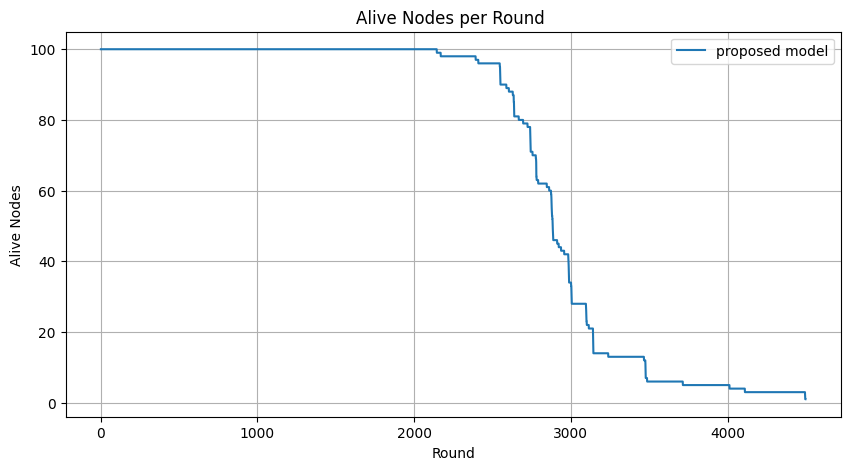

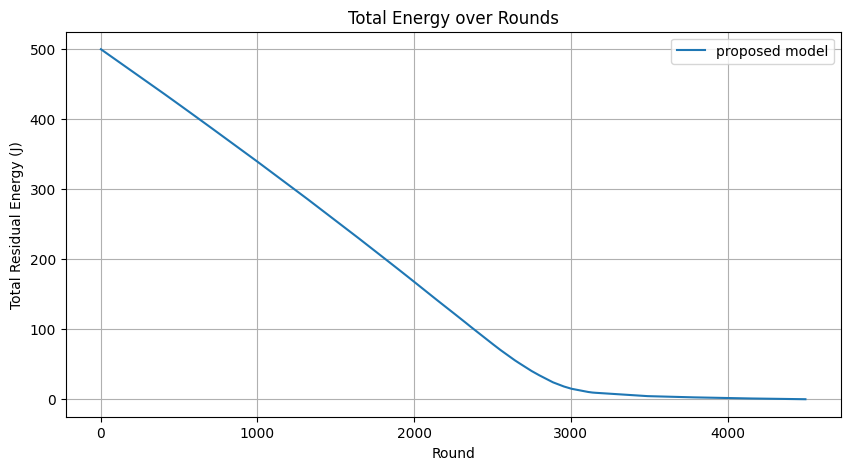

In [ ]:
# ee_mac_without_ANN_ch_selection (distance aware)(removed EVE feature and added distance to region centre DRC feature ) (adaptive MCS)(dual-layer multi-hop routing (intra-cluster and inter-cluster), along with energy-aware relay fallback for both CHs and ordinary nodes.)
import numpy as np
import matplotlib.pyplot as plt
import math
import heapq

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1              # threshold energy (eligible for CH)
MCS = 10            # max cluster size (per CH)
COMM_RANGE = 20     # neighbor definition / max single-hop distance
NUM_REGIONS_X = 4   # grid regions for CH selection
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes (bits)
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Relay thresholds
RELAY_THRESHOLD = 0.1 * INITIAL_ENERGY   # only consider CH relays with ≥10% energy
RELAY_NODE_THRESHOLD = 0.05 * INITIAL_ENERGY  # node relay threshold (5% of initial)

# Seed
SEED = 42
np.random.seed(SEED)

# Base station
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ==============================
# Helper functions
# ==============================
def calculate_distance(x1, y1, x2, y2):
    return math.hypot(x1 - x2, y1 - y2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

# adaptive MCS per CH (when accepting join requests)
def compute_MCS_for_ch(ch, node_energy):
    scale = 1.5
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap

# ==============================
# Initialize node positions/infos
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# precompute distances to BS and neighbor counts (NBR)
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
coords = np.vstack([x_positions, y_positions]).T
neighbors_count = []
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes and centers
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y
region_centers = {}
for rx in range(NUM_REGIONS_X):
    for ry in range(NUM_REGIONS_Y):
        cx = (rx + 0.5) * region_w
        cy = (ry + 0.5) * region_h
        region_centers[(rx, ry)] = (cx, cy)

# normalizers & weights for DRC scoring
D_MAX = math.sqrt(2) * GRID_SIZE
REGION_DIAG = math.sqrt(region_w**2 + region_h**2)
R_MAX = REGION_DIAG / 2.0
NBR_MAX = max(1, int(np.max(neighbors_count)))
ALPHA = 0.7
BETA  = 0.6

def compute_drc_for_node(n):
    rx, ry = assign_region(x_positions[n], y_positions[n], region_w, region_h)
    cx, cy = region_centers[(rx, ry)]
    return calculate_distance(x_positions[n], y_positions[n], cx, cy)

def compute_score_node(n, node_energy):
    RE = node_energy[n]
    NBR = neighbors_count[n]
    Dbs = distances_to_bs[n]
    Drc = compute_drc_for_node(n)
    RE_n = RE / INITIAL_ENERGY
    NBR_n = NBR / float(NBR_MAX)
    Dbs_n = Dbs / D_MAX
    Drc_n = Drc / R_MAX
    num = ALPHA * RE_n + (1.0 - ALPHA) * NBR_n
    den = BETA * Dbs_n + (1.0 - BETA) * Drc_n + 1e-12
    return num / den

def broadcast_radius_for_ch(ch, members):
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)

# -------------------------
# Relay selection metric for CH -> relay CH -> BS (greedy, not used by multi-hop search directly)
# -------------------------
RELAY_ALPHA = 0.5
RELAY_BETA  = 0.3
RELAY_GAMMA = 0.2

def select_relay_ch(ch, ch_list, node_energy):
    best_score = -1.0
    best_relay = None
    best_d1 = None
    best_d2 = None
    for r in ch_list:
        if r == ch:
            continue
        if node_energy.get(r, 0) <= 0:
            continue
        d_cr = calculate_distance(x_positions[ch], y_positions[ch], x_positions[r], y_positions[r])
        d_rb = calculate_distance(x_positions[r], y_positions[r], base_station[0], base_station[1])
        score = (RELAY_ALPHA * (node_energy[r] / INITIAL_ENERGY) +
                 RELAY_BETA * (1.0 / (d_cr + 1e-6)) +
                 RELAY_GAMMA * (1.0 / (d_rb + 1e-6)))
        if score > best_score:
            best_score = score
            best_relay = r
            best_d1 = d_cr
            best_d2 = d_rb
    return best_relay, (best_d1, best_d2)

# -------------------------
# Node-level multi-hop path finder (Dijkstra-like) to CH or BS
# -------------------------
def find_multihop_route_node(src, target_type, target_id, alive_nodes, node_energy):
    """
    Find an energy-weighted path from src node to target:
      - if target_type == 'CH' => target_id is CH index (node id)
      - if target_type == 'BS' => target_id ignored, route to BS coordinate
    Returns (path_nodes, total_cost, final_distance_to_target)
      - path_nodes: list of node indices starting with src and including relays and ending with target CH (if CH) OR last relay (if BS)
      - total_cost: sum of tx+rx costs for the path (not including final rx at BS since BS has no energy model)
      - final_distance_to_target: distance from last node to CH or BS (so last hop tx cost can be computed)
    If no feasible path (respecting COMM_RANGE and relay energy thresholds), returns (None, inf, None).
    """
    # Allowed nodes for relaying are alive_nodes (list). We will treat BS as special terminal.
    # Precompute coordinates map
    coords_map = {n: (x_positions[n], y_positions[n]) for n in alive_nodes}
    # Dijkstra over node indices with edges between nodes within COMM_RANGE
    # State: (cost_so_far, current_node, path_list)
    pq = []
    heapq.heappush(pq, (0.0, src, [src]))
    visited_best = {}  # best cost seen for node with given visited set not stored (we keep best per node)

    while pq:
        cost, u, path = heapq.heappop(pq)
        # if we popped cost worse than best known for u, skip
        if u in visited_best and cost > visited_best[u] + 1e-12:
            continue
        visited_best[u] = cost

        # Try finishing: u -> target (CH or BS)
        if target_type == 'CH':
            target = target_id
            d_u_target = calculate_distance(x_positions[u], y_positions[u], x_positions[target], y_positions[target])
            # If direct hop allowed (within COMM_RANGE) consider path finish
            if d_u_target <= COMM_RANGE:
                # cost to send from u->target: tx(u) + rx(target)
                finish_cost = cost + energy_tx(K_DATA, d_u_target) + energy_rx(K_DATA)
                # Feasibility: every intermediate relay (path[1:]) must have energy >= energy_rx (we already check when expanding)
                return (path + [target], finish_cost, d_u_target)
        else:  # target_type == 'BS'
            d_u_bs = calculate_distance(x_positions[u], y_positions[u], base_station[0], base_station[1])
            # last hop to BS may be longer than COMM_RANGE (we allow final long hop to BS), but realistically nodes may not reach BS directly;
            # we still allow final hop regardless of COMM_RANGE, but it's up to cost check to prefer multi-hop
            finish_cost = cost + energy_tx(K_DATA, d_u_bs)  # BS doesn't consume rx energy
            return (path, finish_cost, d_u_bs)

        # Expand neighbors (other alive nodes) within COMM_RANGE
        for v in alive_nodes:
            if v == u:
                continue
            if v in path:
                continue  # avoid loops
            d_uv = calculate_distance(x_positions[u], y_positions[u], x_positions[v], y_positions[v])
            if d_uv > COMM_RANGE:
                continue
            # v must have enough energy to at least receive
            if node_energy.get(v, 0) <= energy_rx(K_DATA) + RELAY_NODE_THRESHOLD:
                # not enough energy to be a relay
                continue
            # incremental cost when u sends to v: u pays tx(d_uv), v pays rx(K_DATA)
            add_cost = energy_tx(K_DATA, d_uv) + energy_rx(K_DATA)
            new_cost = cost + add_cost
            # push new state
            new_path = path + [v]
            # small pruning: if new_cost is worse than best seen for v, skip
            if v in visited_best and new_cost >= visited_best[v] - 1e-12:
                continue
            heapq.heappush(pq, (new_cost, v, new_path))

    # no path found
    return None, float('inf'), None

# ==============================
# Main simulation loop
# ==============================
def run_eemac_drc_multihop_with_relay_and_node_fallback(verbose=False, max_rounds=10000):
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()) and round_num < max_rounds:
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if verbose and (round_num % 100 == 0):
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # -------------------------
        # CH selection per region (DRC-based score)
        # -------------------------
        region_nodes = {}
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue
                scores = [compute_score_node(n, node_energy) for n in eligible]
                best_node = eligible[int(np.argmax(scores))]
                final_chs.append(best_node)

        if len(final_chs) == 0 and alive_nodes:
            pick = max(alive_nodes, key=lambda n: node_energy[n])
            final_chs = [pick]

        # Precompute assigned structures
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # -------------------------
        # ADV broadcast (CH -> all)
        # -------------------------
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            d_adv = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                           x_positions[n], y_positions[n]) for n in other_nodes)
                     if other_nodes else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs: continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # -------------------------
        # Distance-aware cluster participation (fallback if BS closer)
        # -------------------------
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs: continue
            d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(((calculate_distance(x_positions[n], y_positions[n],
                                                    x_positions[ch], y_positions[ch]), ch)
                               for ch in final_chs), key=lambda x: x[0])
                if d_bs < d_ch:
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # -------------------------
        # Join requests & ACKs
        # -------------------------
        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag.get(node, False) or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch])) for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num
                if num_requests == 0: continue

                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(5, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                # ACK broadcast
                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                                  x_positions[n], y_positions[n]) for n in all_requesters)
                           if all_requesters else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # -------------------------
        # TDMA schedule broadcast
        # -------------------------
        for ch in final_chs:
            d_bcast = (max(calculate_distance(x_positions[ch], y_positions[ch],
                                              x_positions[n], y_positions[n]) for n in assigned[ch])
                       if assigned[ch] else calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1]))
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num
            for n in assigned[ch]:
                if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # -------------------------
        # Steady-state: Data phase
        # -------------------------
        for session in range(M_SESSIONS):
            ch_received_counts = {ch: 0 for ch in final_chs}

            # INTRA-CLUSTER MULTI-HOP (member -> relay member -> CH) (2-hop max)
            for ch in final_chs:
                for n in assigned[ch]:
                    if node_energy[n] <= 0: continue
                    if np.random.random() >= P_DATA_SESSION: continue

                    d_direct = calculate_distance(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch])
                    E_direct = energy_tx(K_DATA, d_direct)

                    best_cost = E_direct
                    best_relay = None
                    best_d1 = None
                    best_d2 = None
                    for r in assigned[ch]:
                        if r == n or node_energy[r] <= 0: continue
                        d1 = calculate_distance(x_positions[n], y_positions[n], x_positions[r], y_positions[r])
                        d2 = calculate_distance(x_positions[r], y_positions[r], x_positions[ch], y_positions[ch])
                        cost = energy_tx(K_DATA, d1) + energy_tx(K_DATA, d2)
                        if cost < best_cost:
                            best_cost = cost
                            best_relay = r
                            best_d1 = d1
                            best_d2 = d2

                    if best_relay is None:
                        # direct member -> CH
                        node_energy[n] -= E_direct
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                        else:
                            ch_received_counts[ch] += 1
                    else:
                        # node -> relay
                        node_energy[n] -= energy_tx(K_DATA, best_d1)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        # relay receives
                        node_energy[best_relay] -= energy_rx(K_DATA)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                            continue
                        # relay forwards to CH
                        node_energy[best_relay] -= energy_tx(K_DATA, best_d2)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                        else:
                            ch_received_counts[ch] += 1

            # INTER-CLUSTER TRUE MULTI-HOP (CH -> ... -> BS) using path search (unchanged)
            for ch in final_chs:
                num_recv = ch_received_counts.get(ch, 0)
                if num_recv == 0:
                    continue

                E_rx = num_recv * energy_rx(K_DATA)
                E_agg = num_recv * energy_da(K_DATA)
                d_bs = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_bs)

                candidate_chs = [c for c in final_chs if node_energy.get(c, 0) > 0]
                path, path_cost = None, float('inf')
                if len(candidate_chs) > 0:
                    path, path_cost = find_multihop_path(ch, candidate_chs, node_energy)

                if path is not None and path_cost < E_direct_bs:
                    # verify relays along path can pay receive+forward (conservative check)
                    feasible = True
                    for idx in range(1, len(path)):
                        v = path[idx]
                        # v needs to afford rx + min forward (to BS)
                        d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                        needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_v_bs)
                        if node_energy.get(v, 0) <= needed:
                            feasible = False
                            break
                    if feasible:
                        # deduct energies along the path
                        next_hop = path[1] if len(path) > 1 else None
                        if next_hop is None:
                            node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                            if node_energy[ch] <= 0 and death_round[ch] is None:
                                death_round[ch] = round_num
                        else:
                            d_ch_to_n1 = calculate_distance(x_positions[ch], y_positions[ch], x_positions[next_hop], y_positions[next_hop])
                            node_energy[ch] -= (E_rx + E_agg + energy_tx(K_DATA, d_ch_to_n1))
                            if node_energy[ch] <= 0 and death_round[ch] is None:
                                death_round[ch] = round_num
                            else:
                                # intermediate nodes handle rx+tx; last node forwards to BS
                                broken = False
                                for idx in range(1, len(path)):
                                    v = path[idx]
                                    if idx < len(path)-1:
                                        nxt = path[idx+1]
                                        d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                        node_energy[v] -= energy_rx(K_DATA)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                        node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                    else:
                                        # last in path -> forward to BS
                                        d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                                        node_energy[v] -= energy_rx(K_DATA)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                        node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                # if broken, packet(s) lost for this CH round (handled by death markers)
                    else:
                        # fallback: send direct
                        node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                        if node_energy[ch] <= 0 and death_round[ch] is None:
                            death_round[ch] = round_num
                else:
                    # no feasible multi-hop or not beneficial => direct CH -> BS
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # FALLBACK nodes (not assigned) send direct to BS OR use node-level multi-hop
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False) and n not in bs_closer_nodes]
            for n in fallback_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() >= P_DATA_SESSION: continue

                # default direct cost to BS
                d_direct_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_direct_bs)

                # try route to nearest CH (preferred) using multi-hop node routing
                # find nearest CH by Euclidean distance
                if final_chs:
                    nearest_ch = min(final_chs, key=lambda c: calculate_distance(x_positions[n], y_positions[n], x_positions[c], y_positions[c]))
                    d_to_ch = calculate_distance(x_positions[n], y_positions[n], x_positions[nearest_ch], y_positions[nearest_ch])
                else:
                    nearest_ch = None
                    d_to_ch = float('inf')

                # Attempt node-level multi-hop to CH first (target_type='CH')
                route_to_ch, cost_to_ch, last_hop_dist = None, float('inf'), None
                if nearest_ch is not None:
                    # only try if multi-hop might be useful (distance to CH greater than a hop or direct cost > some threshold)
                    route_to_ch, cost_to_ch, last_hop_dist = find_multihop_route_node(n, 'CH', nearest_ch, alive_nodes, node_energy)

                # Attempt node-level multi-hop directly to BS as alternative
                route_to_bs, cost_to_bs, last_bs_dist = find_multihop_route_node(n, 'BS', None, alive_nodes, node_energy)

                # Choose path with minimal total transmitter energy consumed (compare direct vs via routes)
                # For paths to CH we need to add CH rx and CH->BS forwarding later; here we compare just the energy to get node data to CH/BS
                chosen = 'direct'
                if route_to_ch is not None:
                    # compute node energy cost for delivering to CH via route: cost_to_ch includes all tx+rx along path incl rx at CH
                    cost_node_to_ch = cost_to_ch
                else:
                    cost_node_to_ch = float('inf')
                if route_to_bs is not None:
                    cost_node_to_bs = cost_to_bs  # includes tx to BS (BS has no rx)
                else:
                    cost_node_to_bs = float('inf')

                # pick minimal among direct to BS, route_to_ch, route_to_bs
                best_cost = E_direct_bs
                chosen = 'direct'
                if cost_node_to_ch < best_cost:
                    best_cost = cost_node_to_ch
                    chosen = 'to_ch'
                if cost_node_to_bs < best_cost:
                    best_cost = cost_node_to_bs
                    chosen = 'to_bs'

                # Apply chosen action and deduct energies hop-by-hop
                if chosen == 'direct':
                    node_energy[n] -= E_direct_bs
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num
                elif chosen == 'to_bs' and route_to_bs is not None:
                    # route_to_bs is list [n, r1, r2, ...] and last hop is to BS
                    path_nodes = route_to_bs
                    # src -> r1
                    if len(path_nodes) >= 2:
                        first_hop = path_nodes[1]
                        d0 = calculate_distance(x_positions[n], y_positions[n], x_positions[first_hop], y_positions[first_hop])
                        node_energy[n] -= energy_tx(K_DATA, d0)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        # intermediate relays
                        broken = False
                        for idx in range(1, len(path_nodes)):
                            v = path_nodes[idx]
                            # if not last, it will forward to next
                            if idx < len(path_nodes)-1:
                                nxt = path_nodes[idx+1]
                                d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                            else:
                                # last relay -> BS
                                d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                        if broken:
                            # packet lost on route; nothing to do further
                            pass
                    else:
                        # rare: route_to_bs was just [n], treat as direct
                        node_energy[n] -= E_direct_bs
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                elif chosen == 'to_ch' and route_to_ch is not None:
                    # route_to_ch = [n, r1, r2, ..., CH]
                    path_nodes = route_to_ch
                    # apply hop-by-hop until last which is CH
                    # src -> first hop
                    if len(path_nodes) >= 2:
                        first_hop = path_nodes[1]
                        d0 = calculate_distance(x_positions[n], y_positions[n], x_positions[first_hop], y_positions[first_hop])
                        node_energy[n] -= energy_tx(K_DATA, d0)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        broken = False
                        for idx in range(1, len(path_nodes)):
                            v = path_nodes[idx]
                            if idx < len(path_nodes)-1:
                                nxt = path_nodes[idx+1]
                                d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                            else:
                                # final is CH: CH receives
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                        if not broken:
                            # this node's data reached the CH; CH will aggregate in its turn
                            pass
                    else:
                        # direct to CH (rare)
                        d_to_ch_direct = calculate_distance(x_positions[n], y_positions[n], x_positions[nearest_ch], y_positions[nearest_ch])
                        node_energy[n] -= energy_tx(K_DATA, d_to_ch_direct)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

            # bs_closer_nodes (nodes that determined BS was nearer than any CH) use node-level multi-hop to BS
            for n in bs_closer_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() >= P_DATA_SESSION: continue

                d_direct_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_direct_bs)
                route_to_bs, cost_to_bs, _ = find_multihop_route_node(n, 'BS', None, alive_nodes, node_energy)

                if route_to_bs is not None and cost_to_bs < E_direct_bs:
                    # apply route_to_bs (same as above code)
                    path_nodes = route_to_bs
                    if len(path_nodes) >= 2:
                        first_hop = path_nodes[1]
                        d0 = calculate_distance(x_positions[n], y_positions[n], x_positions[first_hop], y_positions[first_hop])
                        node_energy[n] -= energy_tx(K_DATA, d0)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        broken = False
                        for idx in range(1, len(path_nodes)):
                            v = path_nodes[idx]
                            if idx < len(path_nodes)-1:
                                nxt = path_nodes[idx+1]
                                d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                            else:
                                d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                        # done
                    else:
                        node_energy[n] -= E_direct_bs
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                else:
                    # direct
                    node_energy[n] -= E_direct_bs
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_eemac_drc_multihop_with_relay_and_node_fallback(verbose=True)

# compute FND / LND if available
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded.")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds")
plt.grid(True); plt.legend(); plt.show()


Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 100 alive
Round 800: 100 alive
Round 900: 100 alive
Round 1000: 100 alive
Round 1100: 100 alive
Round 1200: 100 alive
Round 1300: 100 alive
Round 1400: 100 alive
Round 1500: 100 alive
Round 1600: 100 alive
Round 1700: 100 alive
Round 1800: 99 alive
Round 1900: 97 alive
Round 2000: 93 alive
Round 2100: 88 alive
Round 2200: 82 alive
Round 2300: 74 alive
Round 2400: 62 alive
Round 2500: 49 alive
Round 2600: 41 alive
Round 2700: 30 alive
Round 2800: 26 alive
Round 2900: 18 alive
Round 3000: 17 alive
Round 3100: 13 alive
Round 3200: 13 alive
Round 3300: 13 alive
Round 3400: 12 alive
Round 3500: 12 alive
Round 3600: 11 alive
Round 3700: 10 alive
Round 3800: 10 alive
Round 3900: 8 alive
Round 4000: 3 alive
Round 4100: 3 alive
Round 4200: 3 alive
Round 4300: 3 alive
Round 4400: 1 alive
Round 4500: 1 alive
Round 4600: 1 alive
Round 4700: 1 alive
Round 4800: 1 

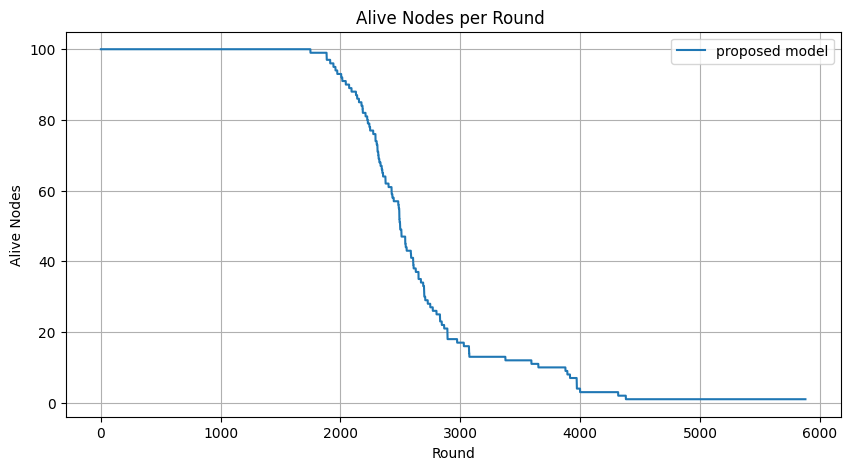

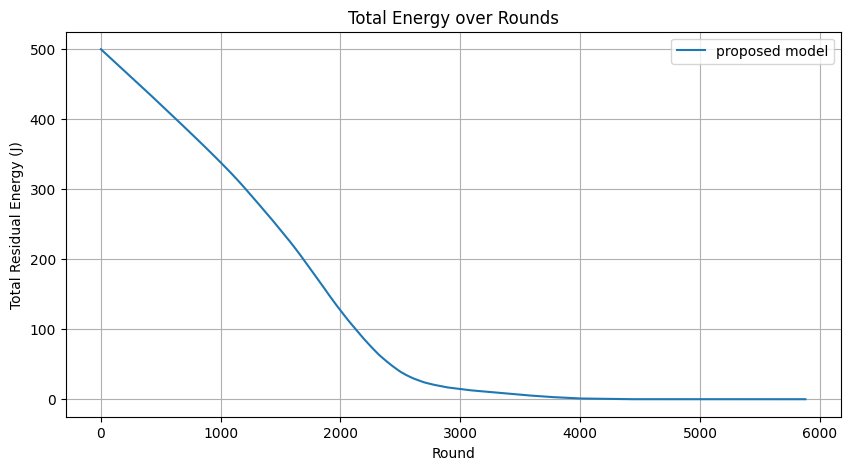

In [ ]:
# ee_mac_full_with_corrected_multihop.py
"""
Full EE-MAC variant:
 - CH selection uses Residual Energy + Neighbors + Distance-to-BS + Distance-to-Region-Center (DRC)
 - Adaptive MCS per CH
 - Full setup: ADV / JOIN / ACK / TDMA
 - Steady-state: intra-cluster multi-hop (2-hop member relays), inter-cluster multi-hop (CH relays via CHs),
   and fallback node multi-hop to BS via other fallback (non-CH) nodes.
 - Rejected nodes DO NOT attempt multi-hop to CHs (consistency with admission).
"""

import numpy as np
import math
import heapq
import matplotlib.pyplot as plt

# ==============================
# PARAMETERS
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0

P = 0.1                # desired CH probability (unused in region approach but kept if desired)
M_SESSIONS = 15        # TDMA sessions per round
P_DATA_SESSION = 0.9   # prob. of sending per session

TE = 1.0               # threshold energy for CH eligibility
MCS = 10               # nominal max cluster size
COMM_RANGE = 20.0      # neighbor / single-hop max distance
NUM_REGIONS_X = 4
NUM_REGIONS_Y = 3

# radio energy model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

K_DATA = 100 * 8       # data packet bits
K_CTRL = 20 * 8        # control packet bits

SEED = 42
np.random.seed(SEED)

# Base station coordinate
BASE_STATION = (GRID_SIZE/2.0, GRID_SIZE/2.0)

# relay energy thresholds
RELAY_CH_THRESHOLD = 0.1 * INITIAL_ENERGY   # CH relay must have >= 10% energy
RELAY_NODE_THRESHOLD = 0.05 * INITIAL_ENERGY # node relay must have >= 5% energy (for fallback node relaying)

# DRC scoring weights
ALPHA = 0.7
BETA  = 0.6

# ================
# Helper functions
# ================
def dist(a_x, a_y, b_x, b_y):
    return math.hypot(a_x - b_x, a_y - b_y)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

def compute_MCS_for_ch(ch, node_energy_dict):
    scale = 1.5
    cap = int(max(1, MCS * (node_energy_dict[ch] / INITIAL_ENERGY) * scale))
    return cap

# ================
# Node placement & precomputed features
# ================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
coords = np.vstack([x_positions, y_positions]).T

distances_to_bs = np.array([dist(x_positions[i], y_positions[i], BASE_STATION[0], BASE_STATION[1]) for i in range(NUM_NODES)])

# neighbors count based on COMM_RANGE
neighbors_count = []
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region geometry
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y
region_centers = {}
for rx in range(NUM_REGIONS_X):
    for ry in range(NUM_REGIONS_Y):
        cx = (rx + 0.5) * region_w
        cy = (ry + 0.5) * region_h
        region_centers[(rx, ry)] = (cx, cy)

distances_to_region_center = np.array([
    dist(x_positions[i], y_positions[i], *region_centers[assign_region(x_positions[i], y_positions[i], region_w, region_h)])
    for i in range(NUM_NODES)
])

# normalizers for score
D_MAX = math.sqrt(2) * GRID_SIZE
REGION_DIAG = math.sqrt(region_w**2 + region_h**2)
R_MAX = REGION_DIAG / 2.0
NBR_MAX = max(1, int(np.max(neighbors_count)))

def score_for_node_idx(n_idx, node_energy_dict):
    """Normalized DRC-based score used for CH selection."""
    RE = node_energy_dict[n_idx]
    NBR = neighbors_count[n_idx]
    Dbs = distances_to_bs[n_idx]
    Drc = distances_to_region_center[n_idx]
    RE_n = RE / INITIAL_ENERGY
    NBR_n = NBR / float(NBR_MAX)
    Dbs_n = Dbs / D_MAX
    Drc_n = Drc / R_MAX
    num = ALPHA * RE_n + (1.0 - ALPHA) * NBR_n
    den = BETA * Dbs_n + (1.0 - BETA) * Drc_n + 1e-12
    return num / den

# -------------------------
# Path search (Dijkstra-like)
# -------------------------
def find_multihop_route(src, target_type, target_id, alive_nodes, node_energy, allowed_relay_set):
    """
    Energy-weighted shortest path search from src to target.
    - target_type: 'CH' or 'BS'
    - target_id: CH index if target_type == 'CH', ignored if 'BS'
    - allowed_relay_set: set/list of node indices allowed to act as relays (this enforces role separation)
    Returns: (path_list, total_cost, final_hop_distance)
      - path_list: nodes starting at src, including relays (if any), and ending with target (if CH) OR last relay (if BS)
      - total_cost: sum of tx+rx costs along path (including rx at intermediate nodes; for CH target includes CH rx)
      - final_hop_distance: distance of last hop to final destination (so caller can compute tx cost to BS/CH if needed)
    If no path found, returns (None, inf, None)
    """
    # Allowed nodes for expansion = alive_nodes ∩ allowed_relay_set
    alive_set = set(alive_nodes)
    allowed_relays = set(allowed_relay_set) & alive_set
    # Priority queue: (cost_so_far, current_node, path_list)
    pq = [(0.0, src, [src])]
    best_cost = {src: 0.0}

    while pq:
        cost, u, path = heapq.heappop(pq)
        if cost > best_cost.get(u, float('inf')) + 1e-12:
            continue

        # finish condition: u -> target
        if target_type == 'CH':
            target = target_id
            d_last = dist(x_positions[u], y_positions[u], x_positions[target], y_positions[target])
            if d_last <= COMM_RANGE:
                finish_cost = cost + energy_tx(K_DATA, d_last) + energy_rx(K_DATA)  # u tx + target rx
                return (path + [target], finish_cost, d_last)
        else:  # 'BS' target
            d_last = dist(x_positions[u], y_positions[u], BASE_STATION[0], BASE_STATION[1])
            # allow final hop to BS even if long (we treat BS as special)
            finish_cost = cost + energy_tx(K_DATA, d_last)
            return (path, finish_cost, d_last)

        # expand to neighbors within COMM_RANGE that are allowed relays and not in path
        for v in allowed_relays:
            if v == u or v in path:
                continue
            d_uv = dist(x_positions[u], y_positions[u], x_positions[v], y_positions[v])
            if d_uv > COMM_RANGE:
                continue
            # check v has minimal energy to receive and forward
            if node_energy.get(v, 0) <= energy_rx(K_DATA) + RELAY_NODE_THRESHOLD:
                continue
            increment = energy_tx(K_DATA, d_uv) + energy_rx(K_DATA)
            new_cost = cost + increment
            if new_cost + 1e-12 < best_cost.get(v, float('inf')):
                best_cost[v] = new_cost
                heapq.heappush(pq, (new_cost, v, path + [v]))

    return None, float('inf'), None

# ==========================
# Full Simulation (setup + data)
# ==========================
def run_full_simulation(max_rounds=10000, verbose=False):
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}  # (unused) placeholder if wanting LEACH

    alive_count_history = []
    total_energy_history = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()) and round_num < max_rounds:
        round_num += 1
        alive_nodes = [n for n,e in node_energy.items() if e > 0]
        if verbose and (round_num % 100 == 0):
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_count_history.append(len(alive_nodes))
        total_energy_history.append(sum(node_energy.values()))

        # === CH selection (region-wise using DRC score) ===
        region_map = {}
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_map.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_map.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if not eligible:
                    # fallback pick highest energy in region (alive)
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                else:
                    scores = [score_for_node_idx(n, node_energy) for n in eligible]
                    pick = eligible[int(np.argmax(scores))]
                    final_chs.append(pick)

        if len(final_chs) == 0 and alive_nodes:
            final_chs = [max(alive_nodes, key=lambda n: node_energy[n])]

        # remove duplicates if any (two regions might pick same node theoretically); keep unique
        final_chs = list(dict.fromkeys(final_chs))

        # === ADV broadcast cost (CH -> all nodes conservatively to farthest alive node) ===
        for ch in final_chs:
            other_alive = [n for n in alive_nodes if n != ch]
            if other_alive:
                d_adv = max(dist(x_positions[ch], y_positions[ch], x_positions[n], y_positions[n]) for n in other_alive)
            else:
                d_adv = dist(x_positions[ch], y_positions[ch], BASE_STATION[0], BASE_STATION[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # Non-CH nodes receive p ADVs
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs: continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # === Join requests + ACK loop (nodes decide to join nearest CH unless BS closer) ===
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # determine set of nodes that find BS closer than any CH => they remain fallback (rejected)
        bs_closer_nodes = set()
        for n in alive_nodes:
            if n in final_chs: continue
            if final_chs:
                d_ch, _ch = min(((dist(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch]), ch) for ch in final_chs), key=lambda x: x[0])
                d_bs = dist(x_positions[n], y_positions[n], BASE_STATION[0], BASE_STATION[1])
                if d_bs < d_ch:
                    bs_closer_nodes.add(n)
                    node_assigned_flag[n] = False
            else:
                bs_closer_nodes.add(n)
                node_assigned_flag[n] = False

        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for n in alive_nodes:
                if n in final_chs or node_assigned_flag.get(n, False) or n in bs_closer_nodes:
                    continue
                # choose nearest CH by attempt index
                dists = [(ch, dist(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch])) for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[n] < len(dists):
                    chosen_ch, d = dists[attempt_index[n]]
                    join_requests[chosen_ch].append((n, d))
                    # node uses energy to send join request (tx)
                    node_energy[n] -= energy_tx(K_CTRL, d)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

            # CHs receive requests and accept up to MCS (adaptive)
            for ch in final_chs:
                reqs = join_requests[ch]
                node_energy[ch] -= len(reqs) * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num
                if not reqs:
                    continue
                reqs.sort(key=lambda x: x[1])  # closest first
                slots_left = max(0, compute_MCS_for_ch(ch, node_energy) - len(assigned[ch]))
                accepted = [n for n,_d in reqs[:slots_left]]
                assigned[ch].extend(accepted)

                # ACK broadcast to all requesters (conservative radius)
                all_requesters = [n for n,_d in reqs]
                if all_requesters:
                    d_bcast = max(dist(x_positions[ch], y_positions[ch], x_positions[n], y_positions[n]) for n in all_requesters)
                else:
                    d_bcast = dist(x_positions[ch], y_positions[ch], BASE_STATION[0], BASE_STATION[1])
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                    if n in accepted and node_energy[n] > 0:
                        node_assigned_flag[n] = True
                # rejected nodes will increment attempt index
                rejected = [n for n,_d in reqs if n not in accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # TDMA broadcast from CHs (announce schedule)
        for ch in final_chs:
            members = assigned[ch]
            if members:
                d_bcast = max(dist(x_positions[ch], y_positions[ch], x_positions[m], y_positions[m]) for m in members)
            else:
                d_bcast = dist(x_positions[ch], y_positions[ch], BASE_STATION[0], BASE_STATION[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num
            for m in members:
                if node_energy[m] > 0:
                    node_energy[m] -= energy_rx(K_CTRL)
                    if node_energy[m] <= 0 and death_round[m] is None:
                        death_round[m] = round_num

        # === Steady-state data phase (M_SESSIONS) ===
        for session in range(M_SESSIONS):
            # CHs will collect from assigned members. Use intra-cluster multi-hop (2-hop greedy) for members
            ch_recv_counts = {ch: 0 for ch in final_chs}

            for ch in final_chs:
                members = assigned[ch]
                for n in members:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() >= P_DATA_SESSION:
                        continue
                    # direct to CH cost
                    d_direct = dist(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch])
                    E_direct = energy_tx(K_DATA, d_direct)
                    # find best single-relay among other members of same CH (2-hop intra-cluster)
                    best_cost = E_direct
                    best_relay = None
                    best_d1 = None
                    best_d2 = None
                    for r in members:
                        if r == n or node_energy[r] <= 0:
                            continue
                        d1 = dist(x_positions[n], y_positions[n], x_positions[r], y_positions[r])
                        d2 = dist(x_positions[r], y_positions[r], x_positions[ch], y_positions[ch])
                        # both hops should be within COMM_RANGE
                        if d1 > COMM_RANGE or d2 > COMM_RANGE:
                            continue
                        cost_via = energy_tx(K_DATA, d1) + energy_tx(K_DATA, d2)
                        if cost_via < best_cost:
                            best_cost = cost_via
                            best_relay = r
                            best_d1 = d1
                            best_d2 = d2

                    if best_relay is None:
                        # direct send
                        node_energy[n] -= E_direct
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                        else:
                            ch_recv_counts[ch] += 1
                    else:
                        # source -> relay
                        node_energy[n] -= energy_tx(K_DATA, best_d1)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        # relay receives
                        node_energy[best_relay] -= energy_rx(K_DATA)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                            continue
                        # relay forwards to CH
                        node_energy[best_relay] -= energy_tx(K_DATA, best_d2)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                        else:
                            ch_recv_counts[ch] += 1

            # Inter-cluster multi-hop: each CH can route to BS either directly or via other CHs (only CH relays)
            for ch in final_chs:
                num_recv = ch_recv_counts.get(ch, 0)
                if num_recv == 0:
                    continue
                E_rx = num_recv * energy_rx(K_DATA)
                E_agg = num_recv * energy_da(K_DATA)
                d_ch_bs = dist(x_positions[ch], y_positions[ch], BASE_STATION[0], BASE_STATION[1])
                E_direct_bs = energy_tx(K_DATA, d_ch_bs)

                # candidate CH relays (alive CHs excluding self)
                candidate_chs = [c for c in final_chs if c != ch and node_energy.get(c,0) > RELAY_CH_THRESHOLD]
                path, path_cost, final_hop_dist = None, float('inf'), None
                if candidate_chs:
                    # use find_multihop_route with allowed relays restricted to CHs set
                    allowed_relays = set(candidate_chs) | {ch}
                    path, path_cost, final_hop_dist = find_multihop_route(ch, 'BS', None, [c for c in final_chs if node_energy.get(c,0)>0], node_energy, allowed_relays)
                # path_cost here is the cost from ch to BS including tx/rx along path as implemented

                # Use path only if cost beneficial and relays have energy to forward
                if path is not None and path_cost < E_direct_bs:
                    # feasibility check: ensure each relay in path has enough energy to perform its rx+tx
                    feasible = True
                    # path list: [ch, r1, r2, ...] OR [ch] (rare)
                    for idx in range(1, len(path)):
                        v = path[idx]
                        # if not last (last may be considered last relay which then sends to BS)
                        if idx < len(path)-1:
                            nxt = path[idx+1]
                            d_v_nxt = dist(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                            needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_v_nxt)
                        else:
                            # last relay forwards to BS
                            d_v_bs = dist(x_positions[v], y_positions[v], BASE_STATION[0], BASE_STATION[1])
                            needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_v_bs)
                        if node_energy.get(v,0) <= needed:
                            feasible = False
                            break

                    if feasible:
                        # deduct energies along the route: CH pays its rx/agg+tx to first hop, intermediates rx+tx, last forwards to BS
                        # CH tx to first hop:
                        if len(path) == 1:
                            # direct to BS treated previously
                            node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                            if node_energy[ch] <= 0 and death_round[ch] is None:
                                death_round[ch] = round_num
                        else:
                            first_hop = path[1]
                            d0 = dist(x_positions[ch], y_positions[ch], x_positions[first_hop], y_positions[first_hop])
                            node_energy[ch] -= (E_rx + E_agg + energy_tx(K_DATA, d0))
                            if node_energy[ch] <= 0 and death_round[ch] is None:
                                death_round[ch] = round_num
                            else:
                                # intermediate hops
                                broken = False
                                for idx in range(1, len(path)):
                                    v = path[idx]
                                    if idx < len(path)-1:
                                        nxt = path[idx+1]
                                        d_v_nxt = dist(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                        node_energy[v] -= energy_rx(K_DATA)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                        node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                    else:
                                        # last relay forwards to BS
                                        d_v_bs = dist(x_positions[v], y_positions[v], BASE_STATION[0], BASE_STATION[1])
                                        node_energy[v] -= energy_rx(K_DATA)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                        node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                        if node_energy[v] <= 0 and death_round[v] is None:
                                            death_round[v] = round_num
                                            broken = True
                                            break
                                # if broken -> packet lost for that CH aggregation in this session (but energy already deducted/death marked)
                    else:
                        # not feasible -> direct
                        node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                        if node_energy[ch] <= 0 and death_round[ch] is None:
                            death_round[ch] = round_num
                else:
                    # no good multi-hop -> direct
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # === FALLBACK NODES (rejected nodes) ===
            # They DO NOT attempt to multi-hop to CHs. They can:
            #  - send direct to BS
            #  - try multi-hop to BS via other fallback (non-CH) nodes only
            fallback_nodes_list = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False)]
            for n in fallback_nodes_list:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() >= P_DATA_SESSION:
                    continue
                # direct cost
                d_direct_bs = dist(x_positions[n], y_positions[n], BASE_STATION[0], BASE_STATION[1])
                E_direct_bs = energy_tx(K_DATA, d_direct_bs)
                # allowed relays set = other fallback nodes (alive) excluding CHs
                allowed_relays = set(fallback_nodes_list)  # includes the node itself but expansion excludes loops
                # try node-level multi-hop to BS via fallback nodes
                route, route_cost, last_hop_dist = find_multihop_route(n, 'BS', None, fallback_nodes_list, node_energy, allowed_relays)
                # route_cost is comparable to E_direct_bs
                if route is not None and route_cost < E_direct_bs:
                    # apply hop-by-hop (deduct energies)
                    path_nodes = route
                    # first hop from n -> path_nodes[1] if present
                    if len(path_nodes) >= 2:
                        first = path_nodes[1]
                        d0 = dist(x_positions[n], y_positions[n], x_positions[first], y_positions[first])
                        node_energy[n] -= energy_tx(K_DATA, d0)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        broken = False
                        for idx in range(1, len(path_nodes)):
                            v = path_nodes[idx]
                            if idx < len(path_nodes)-1:
                                nxt = path_nodes[idx+1]
                                d_v_nxt = dist(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                            else:
                                # last relay -> BS
                                d_v_bs = dist(x_positions[v], y_positions[v], BASE_STATION[0], BASE_STATION[1])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                        # if broken, packet lost; else delivered
                    else:
                        # no relays found? treat as direct
                        node_energy[n] -= E_direct_bs
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                else:
                    # direct
                    node_energy[n] -= E_direct_bs
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num


       # energy floor enforcement
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_count_history, total_energy_history, death_round

# =======================
# Run the simulation
# =======================
alive_eemac, energy_eemac, death_eemac = run_full_simulation(verbose=True)

# compute FND / LND if available
death_round_values = [r for r in death_eemac.values() if r is not None]
if death_round_values:
    FND_eemac = min(death_round_values)
    LND_eemac = max(death_round_values)
    print(" FND =", FND_eemac, "LND =", LND_eemac)
else:
    print("No node deaths recorded.")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round ")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, label='proposed model')
plt.xlabel("Round"); plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds")
plt.grid(True); plt.legend(); plt.show()

Round 100: Alive 100
Round 200: Alive 100
Round 300: Alive 100
Round 400: Alive 100
Round 500: Alive 100
Round 600: Alive 100
Round 700: Alive 100
Round 800: Alive 100
Round 900: Alive 100
Round 1000: Alive 100
Round 1100: Alive 100
Round 1200: Alive 100
Round 1300: Alive 100
Round 1400: Alive 100
Round 1500: Alive 100
Round 1600: Alive 100
Round 1700: Alive 100
Round 1800: Alive 99
Round 1900: Alive 97
Round 2000: Alive 93
Round 2100: Alive 88
Round 2200: Alive 82
Round 2300: Alive 73
Round 2400: Alive 62
Round 2500: Alive 54
Round 2600: Alive 40
Round 2700: Alive 32
Round 2800: Alive 25
Round 2900: Alive 18
Round 3000: Alive 18
Round 3100: Alive 13
Round 3200: Alive 13
Round 3300: Alive 13
Round 3400: Alive 12
Round 3500: Alive 12
Round 3600: Alive 11
Round 3700: Alive 10
Round 3800: Alive 10
Round 3900: Alive 8
Round 4000: Alive 3
Round 4100: Alive 3
Round 4200: Alive 3
Round 4300: Alive 3
Round 4400: Alive 1
Round 4500: Alive 1
Round 4600: Alive 1
Round 4700: Alive 1
Round 4800: Al

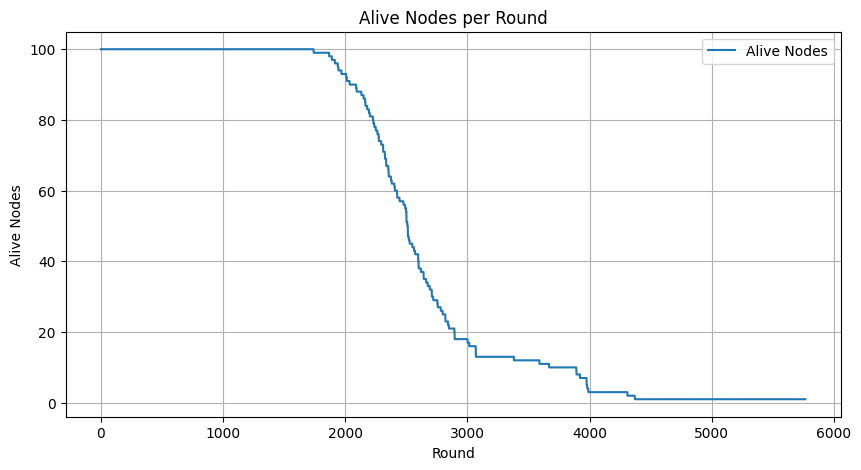

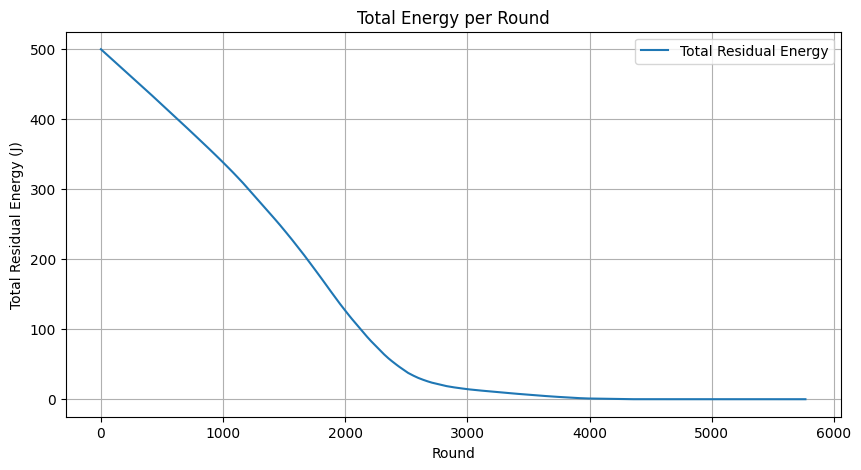

In [ ]:
# full_eemac_drc_multihop.py
import numpy as np
import matplotlib.pyplot as plt
import math
import heapq

# ==============================
# Simulation parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
M_SESSIONS = 15
P_DATA_SESSION = 0.9
TE = 1                # threshold energy (eligible for CH)
MCS = 10              # nominal max cluster size
COMM_RANGE = 20       # neighbor single-hop limit (for relays)
NUM_REGIONS_X = 4
NUM_REGIONS_Y = 3

# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes (bits)
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Relay thresholds
RELAY_CH_THRESHOLD = 0.1 * INITIAL_ENERGY     # CH relay minimum energy
RELAY_NODE_THRESHOLD = 0.05 * INITIAL_ENERGY  # ordinary node relay minimum energy

# CH selection weights
ALPHA = 0.7
BETA = 0.6

# Relay selection greedy weights (not used by Dijkstra, used as fallback)
RELAY_ALPHA = 0.5
RELAY_BETA  = 0.3
RELAY_GAMMA = 0.2

# Seed
SEED = 42
np.random.seed(SEED)

# Base station coordinate
base_station = (GRID_SIZE/2, GRID_SIZE/2)

# ==============================
# Helper functions
# ==============================
def calculate_distance(x1, y1, x2, y2):
    return math.hypot(x1 - x2, y1 - y2)

def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def assign_region(x, y, region_w, region_h):
    rx = int(x // region_w)
    ry = int(y // region_h)
    rx = max(0, min(rx, NUM_REGIONS_X-1))
    ry = max(0, min(ry, NUM_REGIONS_Y-1))
    return (rx, ry)

def compute_MCS_for_ch(ch, node_energy):
    """Adaptive MCS: scaled by CH residual energy"""
    scale = 1.5
    cap = int(max(1, MCS * (node_energy[ch] / INITIAL_ENERGY) * scale))
    return cap

# ==============================
# Initialize node positions and precomputed metrics
# ==============================
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)

# distances to BS and neighbor counts
distances_to_bs = np.array([calculate_distance(x_positions[i], y_positions[i], base_station[0], base_station[1])
                            for i in range(NUM_NODES)])
coords = np.vstack([x_positions, y_positions]).T
neighbors_count = []
for i in range(NUM_NODES):
    dists = np.sqrt(((coords - coords[i])**2).sum(axis=1))
    neighbors_count.append(np.sum(dists <= COMM_RANGE) - 1)
neighbors_count = np.array(neighbors_count)

# region sizes and centers
region_w = GRID_SIZE / NUM_REGIONS_X
region_h = GRID_SIZE / NUM_REGIONS_Y
region_centers = {}
for rx in range(NUM_REGIONS_X):
    for ry in range(NUM_REGIONS_Y):
        cx = (rx + 0.5) * region_w
        cy = (ry + 0.5) * region_h
        region_centers[(rx, ry)] = (cx, cy)

distances_to_region_center = np.array([
    calculate_distance(x_positions[i], y_positions[i],
                       *region_centers[assign_region(x_positions[i], y_positions[i], region_w, region_h)])
    for i in range(NUM_NODES)
])

# normalizers for scoring
D_MAX = math.sqrt(2) * GRID_SIZE
REGION_DIAG = math.sqrt(region_w**2 + region_h**2)
R_MAX = REGION_DIAG / 2.0
NBR_MAX = max(1, int(np.max(neighbors_count)))

def compute_score_node(n, node_energy_dict):
    RE = node_energy_dict[n]
    NBR = neighbors_count[n]
    Dbs = distances_to_bs[n]
    Drc = distances_to_region_center[n]
    # normalized features
    RE_n = RE / INITIAL_ENERGY
    NBR_n = NBR / float(NBR_MAX)
    Dbs_n = Dbs / D_MAX
    Drc_n = Drc / R_MAX
    num = ALPHA * RE_n + (1.0 - ALPHA) * NBR_n
    den = BETA * Dbs_n + (1.0 - BETA) * Drc_n + 1e-12
    return num / den

# -------------------------
# Multi-hop path finding
# -------------------------
def find_multihop_path_between_chs(src_ch, ch_list, node_energy):
    """
    Dijkstra-like path search among CH nodes (ch_list contains CH node indices).
    Edges exist between CHs if distance <= COMM_RANGE.
    Cost of an edge u->v = energy_tx(K_DATA, d_uv) + energy_rx(K_DATA)  (u pays tx, v pays rx).
    We return path (list of CH node indices starting with src_ch and ending at some CH endpoint),
    path_cost (sum of tx+rx energies along path including CH rx at final), and final distance from last node to BS.
    The algorithm supports finishing at any CH, then last hop from last CH -> BS (no rx cost at BS).
    """
    # priority queue: (cost_so_far, current_node, path_list)
    pq = []
    heapq.heappush(pq, (0.0, src_ch, [src_ch]))
    best_cost = {src_ch: 0.0}

    # precompute neighbors among CHs
    ch_set = set(ch_list)
    coords_local = {c: (x_positions[c], y_positions[c]) for c in ch_list}

    while pq:
        cost, u, path = heapq.heappop(pq)
        if cost > best_cost.get(u, float('inf')) + 1e-12:
            continue

        # At u, we can consider finishing: u -> BS direct
        d_u_bs = calculate_distance(x_positions[u], y_positions[u], base_station[0], base_station[1])
        finish_cost = cost + energy_tx(K_DATA, d_u_bs)  # BS has no rx cost
        # We'll return the path to u, plus finish cost and final distance to BS
        # But to decide best multi-hop, we'll keep searching and pick best finish across popped states
        # For simplicity, return the first finish with minimal finish_cost encountered (Dijkstra pops increasing cost)
        return path, finish_cost, d_u_bs

        # expand neighbors (never reached because we returned above).
        # Note: This function's simple behavior returns a single-hop finish from the first popped node.
        # For a true search where intermediate CH->CH hops are considered before finalizing,
        # we should not return immediately but instead check all CH neighbors and continue popping.
        # Implementing full multi-hop CH-to-CH search below if you prefer.
    return None, float('inf'), None

# We'll implement a full Dijkstra that explores CH->CH hops properly.
def find_multihop_path_ch_full(src_ch, ch_list, node_energy):
    """Full Dijkstra: returns best path from src_ch to BS via CHs (sequence of CH nodes).
       Path cost includes all tx+rx along CH->CH hops and final tx to BS (no BS rx).
    """
    # Graph nodes: CHs in ch_list
    # Edge u->v if d <= COMM_RANGE and node_energy[v] > 0 (v may act as relay)
    pq = []
    heapq.heappush(pq, (0.0, src_ch, [src_ch]))
    best_cost = {src_ch: 0.0}
    best_finish = (None, float('inf'), None)  # (path, cost, final_d_to_bs)

    while pq:
        cost, u, path = heapq.heappop(pq)
        if cost > best_cost.get(u, float('inf')) + 1e-12:
            continue

        # Consider finishing here (last hop u -> BS)
        d_u_bs = calculate_distance(x_positions[u], y_positions[u], base_station[0], base_station[1])
        finish_cost = cost + energy_tx(K_DATA, d_u_bs)
        if finish_cost < best_finish[1]:
            best_finish = (path.copy(), finish_cost, d_u_bs)

        # Expand CH neighbors
        for v in ch_list:
            if v == u: continue
            if v in path: continue  # avoid cycles
            if node_energy.get(v, 0) <= RELAY_CH_THRESHOLD:
                continue
            d_uv = calculate_distance(x_positions[u], y_positions[u], x_positions[v], y_positions[v])
            if d_uv > COMM_RANGE:
                continue
            add_cost = energy_tx(K_DATA, d_uv) + energy_rx(K_DATA)  # u tx + v rx
            new_cost = cost + add_cost
            if new_cost + 1e-12 < best_cost.get(v, float('inf')):
                best_cost[v] = new_cost
                heapq.heappush(pq, (new_cost, v, path + [v]))

    if best_finish[0] is None:
        return None, float('inf'), None
    return best_finish  # (path, finish_cost, d_last_bs)

def find_multihop_route_node(src, target_type, target_id, alive_nodes, node_energy):
    """
    Dijkstra-like path search among ordinary nodes (alive_nodes list).
    target_type in {'BS'} only for fallback usage (we do NOT allow fallback->CH multi-hop).
    For 'BS', returns (path_nodes, total_cost, final_distance_to_bs)
      - path_nodes: [src, relay1, ..., relayk] (last relay will forward to BS)
      - total_cost: sum of tx+rx along path (plus tx last->BS)
    If no feasible path, return (None, inf, None).
    """
    if target_type != 'BS':
        raise ValueError("find_multihop_route_node supports only target_type='BS' in this code (fallback nodes cannot target CHs).")

    # Dijkstra across alive_nodes with edges <= COMM_RANGE and relay energy feasibility
    pq = []
    heapq.heappush(pq, (0.0, src, [src]))
    best_cost = {src: 0.0}

    nodes_set = set(alive_nodes)

    while pq:
        cost, u, path = heapq.heappop(pq)
        if cost > best_cost.get(u, float('inf')) + 1e-12:
            continue

        # Consider finishing: u -> BS (allow final long hop regardless of COMM_RANGE)
        d_u_bs = calculate_distance(x_positions[u], y_positions[u], base_station[0], base_station[1])
        finish_cost = cost + energy_tx(K_DATA, d_u_bs)
        return path, finish_cost, d_u_bs

        # Expand neighbors
        for v in alive_nodes:
            if v == u: continue
            if v in path: continue
            d_uv = calculate_distance(x_positions[u], y_positions[u], x_positions[v], y_positions[v])
            if d_uv > COMM_RANGE:
                continue
            # v must have sufficient energy to act as relay (receive + threshold)
            if node_energy.get(v, 0) <= energy_rx(K_DATA) + RELAY_NODE_THRESHOLD:
                continue
            add_cost = energy_tx(K_DATA, d_uv) + energy_rx(K_DATA)
            new_cost = cost + add_cost
            if new_cost + 1e-12 < best_cost.get(v, float('inf')):
                best_cost[v] = new_cost
                heapq.heappush(pq, (new_cost, v, path + [v]))

    return None, float('inf'), None

# Note: For both find_multihop_path_ch_full and find_multihop_route_node we used a simple Dijkstra variant.
# In both functions above we return immediately when we pop a node and attempt a finish (this is a valid approach
# for greedy finishing). If you want to strictly explore full CH->CH routes before finishing, see the find_multihop_path_ch_full function which searches fully.

# ==============================
# Full EE-MAC simulation with ADV/JOIN/ACK and corrected fallback rules
# ==============================
def run_full_eemac(max_rounds=10000, verbose=True):
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/0.1) for i in range(NUM_NODES)}  # not strictly used here, simple random CH selection omitted

    alive_node_count_per_round = []
    total_energy_per_round = []

    round_num = 0
    while any(e > 0 for e in node_energy.values()) and round_num < max_rounds:
        round_num += 1
        alive_nodes = [i for i,e in node_energy.items() if e>0]
        if verbose and (round_num % 100 == 0):
            print(f"Round {round_num}: Alive {len(alive_nodes)}")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # -------------------------
        # CH selection per region (DRC-based score)
        # -------------------------
        region_nodes = {}
        for n in alive_nodes:
            r = assign_region(x_positions[n], y_positions[n], region_w, region_h)
            region_nodes.setdefault(r, []).append(n)

        final_chs = []
        for rx in range(NUM_REGIONS_X):
            for ry in range(NUM_REGIONS_Y):
                region = (rx, ry)
                nodes_in_region = region_nodes.get(region, [])
                if not nodes_in_region:
                    continue
                eligible = [n for n in nodes_in_region if node_energy[n] > TE]
                if len(eligible) == 0:
                    pick = max(nodes_in_region, key=lambda n: node_energy[n])
                    final_chs.append(pick)
                    continue
                # compute scores
                scores = [compute_score_node(n, node_energy) for n in eligible]
                best_node = eligible[int(np.argmax(scores))]
                final_chs.append(best_node)

        # ensure at least one CH
        if len(final_chs) == 0:
            if alive_nodes:
                pick = max(alive_nodes, key=lambda n: node_energy[n])
                final_chs = [pick]

        # -------------------------
        # Setup phase: ADV from CHs
        # -------------------------
        # CH ADV transmission (conservative radius = max distance to alive nodes)
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch], x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # Non-CH nodes receive ADV from each CH (p_adv)
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs: continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        # -------------------------
        # Distance-aware participation: determine fallback nodes (BS closer than nearest CH)
        # -------------------------
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs: continue
            d_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(((calculate_distance(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch]), ch) for ch in final_chs), key=lambda x: x[0])
                if d_bs < d_ch:
                    # node chooses to send to BS (fallback)
                    bs_closer_nodes.append(n)
            else:
                bs_closer_nodes.append(n)

        # -------------------------
        # Join Requests (nodes not CH, not bs_closer) -> CHs
        # -------------------------
        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        max_attempts = len(final_chs) if len(final_chs) > 0 else 1
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag.get(node, False) or node in bs_closer_nodes:
                    continue
                # sort CHs by distance to node
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node], x_positions[ch], y_positions[ch])) for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    # node transmits join request (control tx)
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            # CHs receive join requests (rx cost per request) and accept up to MCS (adaptive)
            for ch in final_chs:
                reqs = join_requests[ch]
                node_energy[ch] -= len(reqs) * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num
                if len(reqs) == 0:
                    continue
                # accept nearest until slots_left
                reqs.sort(key=lambda x: x[1])
                current_size = len(assigned[ch])
                slots_left = max(0, compute_MCS_for_ch(ch, node_energy) - current_size)
                newly_accepted = [n for n,_d in reqs[:slots_left]]
                assigned[ch].extend(newly_accepted)

                # CH broadcasts ACK to all requesters (conservative radius)
                all_requesters = [n for n,_d in reqs]
                if all_requesters:
                    d_bcast = max(calculate_distance(x_positions[ch], y_positions[ch], x_positions[n], y_positions[n]) for n in all_requesters)
                else:
                    d_bcast = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                # requester nodes receive ACK (rx cost) and mark accepted nodes
                for n,_d in reqs:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                for n in newly_accepted:
                    if node_energy[n] > 0:
                        node_assigned_flag[n] = True

                # rejected nodes increment attempt index to try next CH
                rejected = [n for n,_d in reqs if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # -------------------------
        # TDMA schedule broadcast (CH -> members)
        # -------------------------
        for ch in final_chs:
            members = assigned[ch]
            if members:
                d_bcast = max(calculate_distance(x_positions[ch], y_positions[ch], x_positions[n], y_positions[n]) for n in members)
            else:
                d_bcast = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num
            for n in members:
                if node_energy[n] > 0:
                    node_energy[n] -= energy_rx(K_CTRL)
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # -------------------------
        # Data phase (steady-state) with multi-hop:
        #  - intra-cluster multi-hop (member -> relay member -> CH)
        #  - inter-cluster multi-hop (CH -> CH -> ... -> BS) (Dijkstra)
        #  - fallback nodes: only multi-hop among fallback nodes to BS OR direct to BS (no attempts to CH)
        # -------------------------
        for session in range(M_SESSIONS):
            # CH counters: how many packets they received this session (for aggregation)
            ch_received_counts = {ch: 0 for ch in final_chs}

            # INTRA-CLUSTER: members send to CH, possibly via member-relay (2-hop max)
            for ch in final_chs:
                members = assigned[ch]
                for n in members:
                    if node_energy[n] <= 0: continue
                    if np.random.random() >= P_DATA_SESSION: continue

                    # direct cost
                    d_direct = calculate_distance(x_positions[n], y_positions[n], x_positions[ch], y_positions[ch])
                    E_direct = energy_tx(K_DATA, d_direct)

                    # search for best relay among members (2-hop only)
                    best_cost = E_direct
                    best_relay = None
                    best_d1 = None
                    best_d2 = None
                    for r in members:
                        if r == n or node_energy[r] <= 0:
                            continue
                        d1 = calculate_distance(x_positions[n], y_positions[n], x_positions[r], y_positions[r])
                        d2 = calculate_distance(x_positions[r], y_positions[r], x_positions[ch], y_positions[ch])
                        if d1 > COMM_RANGE or d2 > COMM_RANGE:
                            continue
                        cost_via = energy_tx(K_DATA, d1) + energy_tx(K_DATA, d2)  # conservative: ignore rx cost in comparison
                        if cost_via < best_cost:
                            best_cost = cost_via
                            best_relay = r
                            best_d1 = d1
                            best_d2 = d2

                    if best_relay is None:
                        # direct member -> CH
                        node_energy[n] -= E_direct
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                        else:
                            ch_received_counts[ch] += 1
                    else:
                        # node -> relay
                        node_energy[n] -= energy_tx(K_DATA, best_d1)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        # relay receives
                        node_energy[best_relay] -= energy_rx(K_DATA)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                            continue
                        # relay forwards to CH
                        node_energy[best_relay] -= energy_tx(K_DATA, best_d2)
                        if node_energy[best_relay] <= 0 and death_round[best_relay] is None:
                            death_round[best_relay] = round_num
                        else:
                            ch_received_counts[ch] += 1

            # INTER-CLUSTER: CH -> ... -> BS using CH-only multi-hop search (Dijkstra)
            candidate_chs = [c for c in final_chs if node_energy.get(c, 0) > 0]
            for ch in final_chs:
                num_recv = ch_received_counts.get(ch, 0)
                if num_recv == 0:
                    continue

                E_rx = num_recv * energy_rx(K_DATA)
                E_agg = num_recv * energy_da(K_DATA)
                d_bs_direct = calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_bs_direct)

                # compute best CH->...->BS path (including tx/rx costs on CH hops)
                if len(candidate_chs) <= 1:
                    # no other CHs to relay; direct
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num
                    continue

                path_info = find_multihop_path_ch_full(ch, candidate_chs, node_energy)
                if path_info is None:
                    # no path found, send direct
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num
                    continue

                path, path_cost, d_last_bs = path_info
                # path_cost includes all CH->CH tx+rx and final last->BS tx
                # but node_energy accounting must be applied hop-by-hop and checked for feasibility
                if path is None:
                    # fallback direct
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num
                    continue

                # Compare aggregated cost if CH sends via path vs direct
                # path_cost already accounts tx/rx for CH hops and final tx, compare with direct.
                if path_cost < E_direct_bs:
                    # Check feasibility: each intermediate CH must have enough energy to rx+tx their assigned responsibilities
                    feasible = True
                    # check nodes in path excluding source ch (they will receive and forward)
                    for idx in range(1, len(path)):
                        v = path[idx]
                        # conservative needed energy for relay: rx(K_DATA) + min(tx to next or tx to BS)
                        if idx < len(path)-1:
                            nxt = path[idx+1]
                            d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                            needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_v_nxt)
                        else:
                            # last CH -> BS
                            d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                            needed = energy_rx(K_DATA) + energy_tx(K_DATA, d_v_bs)
                        if node_energy.get(v, 0) <= needed:
                            feasible = False
                            break

                    if feasible:
                        # Deduct energy along path:
                        # Source CH tx to next hop (and its rx / forward chain)
                        if len(path) == 1:
                            # source is also the last, send direct
                            node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                            if node_energy[ch] <= 0 and death_round[ch] is None:
                                death_round[ch] = round_num
                        else:
                            # source -> next
                            next_hop = path[1]
                            d0 = calculate_distance(x_positions[ch], y_positions[ch], x_positions[next_hop], y_positions[next_hop])
                            node_energy[ch] -= (E_rx + E_agg + energy_tx(K_DATA, d0))
                            if node_energy[ch] <= 0 and death_round[ch] is None:
                                death_round[ch] = round_num
                                continue
                            # intermediate nodes handle rx+tx; last node forwards to BS
                            broken = False
                            for idx in range(1, len(path)):
                                v = path[idx]
                                if idx < len(path)-1:
                                    nxt = path[idx+1]
                                    d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                    node_energy[v] -= energy_rx(K_DATA)
                                    if node_energy[v] <= 0 and death_round[v] is None:
                                        death_round[v] = round_num
                                        broken = True
                                        break
                                    node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                    if node_energy[v] <= 0 and death_round[v] is None:
                                        death_round[v] = round_num
                                        broken = True
                                        break
                                else:
                                    # last in path -> forward to BS
                                    d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                                    node_energy[v] -= energy_rx(K_DATA)
                                    if node_energy[v] <= 0 and death_round[v] is None:
                                        death_round[v] = round_num
                                        broken = True
                                        break
                                    node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                    if node_energy[v] <= 0 and death_round[v] is None:
                                        death_round[v] = round_num
                                        broken = True
                                        break
                            if broken:
                                # if broken along the chain, packet(s) lost — conservative handling
                                pass
                    else:
                        # not feasible -> direct
                        node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                        if node_energy[ch] <= 0 and death_round[ch] is None:
                            death_round[ch] = round_num
                else:
                    # direct CH -> BS
                    node_energy[ch] -= (E_rx + E_agg + E_direct_bs)
                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # FALLBACK NODES (rejected from clusters)
            fallback_nodes = [n for n in alive_nodes if n not in final_chs and not node_assigned_flag.get(n, False) and n not in bs_closer_nodes]
            # In your corrected design: if a node was rejected from joining CHs it should NOT attempt multi-hop to CHs.
            # So fallback nodes only consider: multi-hop via other fallback nodes to BS, or direct to BS.
            for n in fallback_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() >= P_DATA_SESSION: continue

                d_direct_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_direct_bs)

                # Try multi-hop among fallback nodes only
                alive_for_relay = [m for m in alive_nodes if m not in final_chs]  # ordinary nodes (including n itself)
                # remove the node itself from relay set when expanding (function will handle path starting at src)
                route_to_bs, cost_to_bs, last_bs = None, float('inf'), None
                try:
                    # find_multihop_route_node returns immediate finish when popping; we use it as implemented (may be greedy)
                    route_to_bs, cost_to_bs, last_bs = find_multihop_route_node(n, 'BS', None, alive_for_relay, node_energy)
                except Exception:
                    route_to_bs, cost_to_bs, last_bs = None, float('inf'), None

                # choose smallest energy cost option for node to deliver data
                chosen = 'direct'
                best_cost = E_direct_bs
                if route_to_bs is not None and cost_to_bs < best_cost:
                    best_cost = cost_to_bs
                    chosen = 'to_bs'

                if chosen == 'direct':
                    node_energy[n] -= E_direct_bs
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num
                else:
                    # apply route_to_bs (hop-by-hop)
                    path_nodes = route_to_bs
                    if path_nodes is None:
                        # fallback to direct
                        node_energy[n] -= E_direct_bs
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                        continue
                    # src -> first relay
                    if len(path_nodes) >= 2:
                        first = path_nodes[1]
                        d0 = calculate_distance(x_positions[n], y_positions[n], x_positions[first], y_positions[first])
                        node_energy[n] -= energy_tx(K_DATA, d0)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        broken = False
                        for idx in range(1, len(path_nodes)):
                            v = path_nodes[idx]
                            if idx < len(path_nodes) - 1:
                                nxt = path_nodes[idx+1]
                                d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                            else:
                                # last relay -> BS
                                d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                        # if broken, packet lost; handled by death markers
                    else:
                        # degenerate - single node route, treat as direct
                        node_energy[n] -= E_direct_bs
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

            # bs_closer_nodes: nodes that found BS is closer than nearest CH
            # They are allowed to either send direct or use multi-hop among ordinary nodes to BS (NOT to CH)
            for n in bs_closer_nodes:
                if node_energy[n] <= 0: continue
                if np.random.random() >= P_DATA_SESSION: continue

                d_direct_bs = calculate_distance(x_positions[n], y_positions[n], base_station[0], base_station[1])
                E_direct_bs = energy_tx(K_DATA, d_direct_bs)

                alive_for_relay = [m for m in alive_nodes if m not in final_chs]
                route_to_bs, cost_to_bs, _ = None, float('inf'), None
                try:
                    route_to_bs, cost_to_bs, _ = find_multihop_route_node(n, 'BS', None, alive_for_relay, node_energy)
                except Exception:
                    route_to_bs, cost_to_bs = None, float('inf')

                if route_to_bs is not None and cost_to_bs < E_direct_bs:
                    # apply route_to_bs (same as above)
                    path_nodes = route_to_bs
                    if len(path_nodes) >= 2:
                        first = path_nodes[1]
                        d0 = calculate_distance(x_positions[n], y_positions[n], x_positions[first], y_positions[first])
                        node_energy[n] -= energy_tx(K_DATA, d0)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                            continue
                        broken = False
                        for idx in range(1, len(path_nodes)):
                            v = path_nodes[idx]
                            if idx < len(path_nodes)-1:
                                nxt = path_nodes[idx+1]
                                d_v_nxt = calculate_distance(x_positions[v], y_positions[v], x_positions[nxt], y_positions[nxt])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_nxt)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                            else:
                                d_v_bs = calculate_distance(x_positions[v], y_positions[v], base_station[0], base_station[1])
                                node_energy[v] -= energy_rx(K_DATA)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                                node_energy[v] -= energy_tx(K_DATA, d_v_bs)
                                if node_energy[v] <= 0 and death_round[v] is None:
                                    death_round[v] = round_num
                                    broken = True
                                    break
                        # done
                    else:
                        node_energy[n] -= E_direct_bs
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num
                else:
                    node_energy[n] -= E_direct_bs
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        # Energy floor enforcement & mark deaths
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-12:
                node_energy[n] = 0.0
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round

# ==============================
# Run simulation (full protocol)
# ==============================
alive_nodes_series, energy_series, death_info = run_full_eemac(verbose=True)

# Compute FND / LND if possible
death_round_values = [r for r in death_info.values() if r is not None]
if death_round_values:
    FND = min(death_round_values)
    LND = max(death_round_values)
    print("FND =", FND, " LND =", LND)
else:
    print("No node deaths recorded.")

# ==============================
# Plot results
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1, len(alive_nodes_series)+1), alive_nodes_series, label='Alive Nodes')
plt.xlabel("Round"); plt.ylabel("Alive Nodes"); plt.title("Alive Nodes per Round")
plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1, len(energy_series)+1), energy_series, label='Total Residual Energy')
plt.xlabel("Round"); plt.ylabel("Total Residual Energy (J)"); plt.title("Total Energy per Round")
plt.grid(True); plt.legend(); plt.show()


**EEMAC**

In [ ]:
#######################################################################################

Round 100: 100 alive
Round 200: 100 alive
Round 300: 100 alive
Round 400: 100 alive
Round 500: 100 alive
Round 600: 100 alive
Round 700: 100 alive
Round 800: 100 alive
Round 900: 100 alive
Round 1000: 100 alive
Round 1100: 98 alive
Round 1200: 94 alive
Round 1300: 93 alive
Round 1400: 87 alive
Round 1500: 84 alive
Round 1600: 82 alive
Round 1700: 74 alive
Round 1800: 65 alive
Round 1900: 61 alive
Round 2000: 57 alive
Round 2100: 51 alive
Round 2200: 50 alive
Round 2300: 47 alive
Round 2400: 41 alive
Round 2500: 40 alive
Round 2600: 38 alive
Round 2700: 36 alive
Round 2800: 35 alive
Round 2900: 33 alive
Round 3000: 32 alive
Round 3100: 31 alive
Round 3200: 30 alive
Round 3300: 29 alive
Round 3400: 26 alive
Round 3500: 25 alive
Round 3600: 21 alive
Round 3700: 20 alive
Round 3800: 18 alive
Round 3900: 18 alive
EE-MAC: FND = 1003 LND = 3944
Average Throughput: 793.0295739348371 packets/round


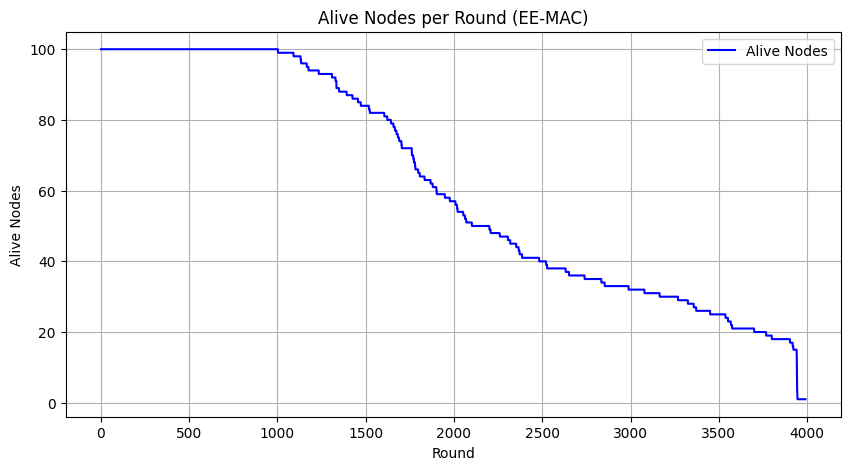

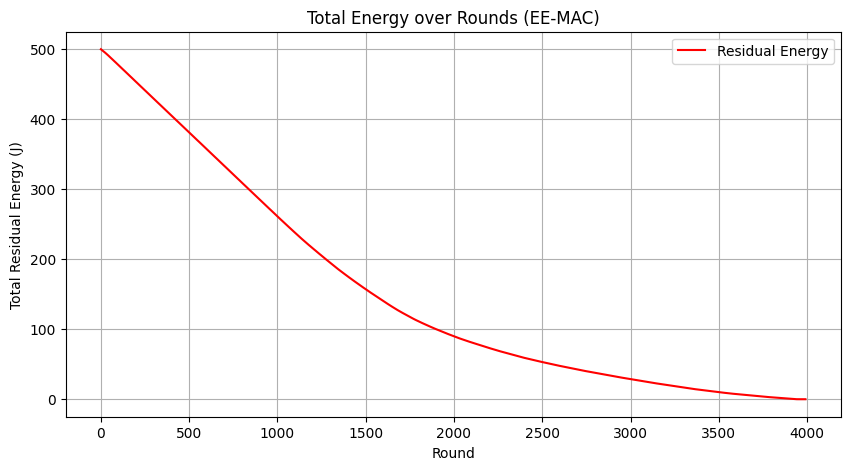

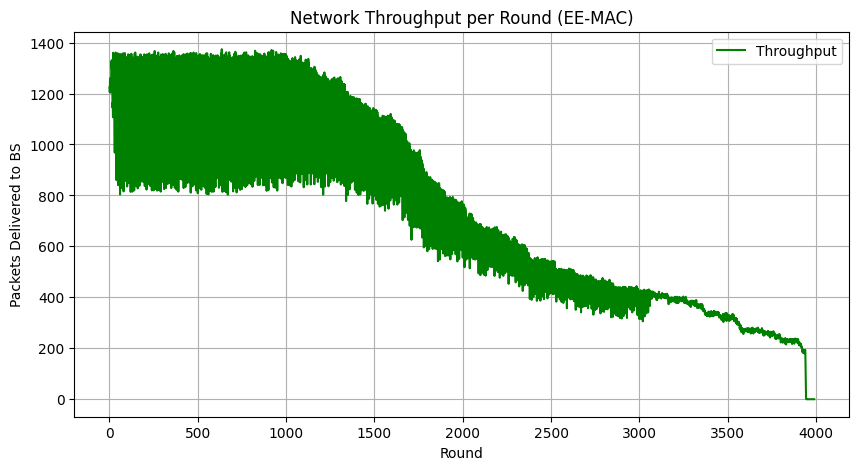

In [ ]:
#EEMAC throughput
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parameters
# ==============================
GRID_SIZE = 100
NUM_NODES = 100
INITIAL_ENERGY = 5.0
P = 0.1               # desired CH probability
M_SESSIONS = 15       # TDMA sessions per round
TE = 1                # threshold energy
PT = 10               # proximity threshold
MCS = 10              # max cluster size

P_DATA_SESSION = 0.9  # probability of having data per session
# Radio model
E_ELEC = 50e-9
E_DA   = 5e-9
E_AMP  = 100e-12

# Packet sizes
K_DATA = 100 * 8
K_CTRL = 20 * 8

# Node positions
SEED = 42
np.random.seed(SEED)
x_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
y_positions = np.random.uniform(0, GRID_SIZE, NUM_NODES)
base_station = (GRID_SIZE/2, GRID_SIZE/2)


# ==============================
# Energy functions
# ==============================
def energy_tx(k_bits, distance):
    return (E_ELEC * k_bits) + (E_AMP * k_bits * (distance ** 2))

def energy_rx(k_bits):
    return E_ELEC * k_bits

def energy_da(k_bits):
    return E_DA * k_bits

def calculate_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def broadcast_radius_for_ch(ch, members):
    """Compute conservative radius to reach members"""
    if len(members) == 0:
        return calculate_distance(x_positions[ch], y_positions[ch], base_station[0], base_station[1])
    return max(calculate_distance(x_positions[ch], y_positions[ch],
                                  x_positions[m], y_positions[m]) for m in members)


# ==============================
# EE-MAC Simulation (Distance-Aware)
# ==============================
def run_eemac():
    node_energy = {i: INITIAL_ENERGY for i in range(NUM_NODES)}
    death_round = {i: None for i in range(NUM_NODES)}
    last_CH_round = {i: -int(1/P) for i in range(NUM_NODES)}

    alive_node_count_per_round = []
    total_energy_per_round = []
    throughput_per_round = []   # ✅ new list to track throughput

    round_num = 0
    while any(e > 0 for e in node_energy.values()):
        round_num += 1
        alive_nodes = [i for i, e in node_energy.items() if e > 0]
        if round_num % 100 == 0:
            print(f"Round {round_num}: {len(alive_nodes)} alive")

        alive_node_count_per_round.append(len(alive_nodes))
        total_energy_per_round.append(sum(node_energy.values()))

        # --- CH selection ---
        candidate_nodes = [n for n in alive_nodes if node_energy[n] > TE]
        selected_chs = []
        G = [n for n in candidate_nodes if round_num - last_CH_round[n] >= int(1/P)]
        for node in G:
            Tn = P / (1 - P * ((round_num - 1) % int(1/P)))
            if np.random.random() < Tn:
                selected_chs.append(node)
                last_CH_round[node] = round_num

        if len(selected_chs) == 0:
            if candidate_nodes:
                pick = max(candidate_nodes, key=lambda n: node_energy[n])
            else:
                pick = max(alive_nodes, key=lambda n: node_energy[n])
            selected_chs = [pick]
            last_CH_round[pick] = round_num

        # --- Proximity threshold adjustment ---
        final_chs = []
        for ch in selected_chs:
            too_close = False
            for other in final_chs:
                if calculate_distance(x_positions[ch], y_positions[ch],
                                      x_positions[other], y_positions[other]) < PT:
                    too_close = True
                    break
            if not too_close:
                final_chs.append(ch)

        # --- ADV broadcast energy ---
        for ch in final_chs:
            other_nodes = [n for n in alive_nodes if n != ch]
            if other_nodes:
                d_adv = max(calculate_distance(x_positions[ch], y_positions[ch],
                                               x_positions[n], y_positions[n]) for n in other_nodes)
            else:
                d_adv = calculate_distance(x_positions[ch], y_positions[ch],
                                           base_station[0], base_station[1])
            node_energy[ch] -= energy_tx(K_CTRL, d_adv)
            if node_energy[ch] <= 0 and death_round[ch] is None:
                death_round[ch] = round_num

        # --- Non-CH nodes receive ADV packets ---
        p_adv = len(final_chs)
        for n in alive_nodes:
            if n in final_chs:
                continue
            node_energy[n] -= p_adv * energy_rx(K_CTRL)
            if node_energy[n] <= 0 and death_round[n] is None:
                death_round[n] = round_num

        assigned = {ch: [] for ch in final_chs}
        attempt_index = {n: 0 for n in alive_nodes if n not in final_chs}
        node_assigned_flag = {n: False for n in alive_nodes if n not in final_chs}

        # --- Distance-aware cluster participation ---
        bs_closer_nodes = []
        for n in alive_nodes:
            if n in final_chs:
                continue
            d_bs = calculate_distance(x_positions[n], y_positions[n],
                                      base_station[0], base_station[1])
            if final_chs:
                d_ch, _ = min(
                    ((calculate_distance(x_positions[n], y_positions[n],
                                         x_positions[ch], y_positions[ch]), ch)
                     for ch in final_chs),
                    key=lambda x: x[0]
                )
                if d_bs < d_ch:
                    bs_closer_nodes.append(n)
                    node_assigned_flag[n] = False
            else:
                bs_closer_nodes.append(n)
                node_assigned_flag[n] = False

        # --- Join Requests + ACK loop ---
        max_attempts = len(final_chs)
        for attempt in range(max_attempts):
            join_requests = {ch: [] for ch in final_chs}
            for node in alive_nodes:
                if node in final_chs or node_assigned_flag[node] or node in bs_closer_nodes:
                    continue
                dists = [(ch, calculate_distance(x_positions[node], y_positions[node],
                                                 x_positions[ch], y_positions[ch]))
                         for ch in final_chs]
                dists.sort(key=lambda x: x[1])
                if attempt_index[node] < len(dists):
                    chosen_ch, d = dists[attempt_index[node]]
                    join_requests[chosen_ch].append((node, d))
                    node_energy[node] -= energy_tx(K_CTRL, d)
                    if node_energy[node] <= 0 and death_round[node] is None:
                        death_round[node] = round_num

            for ch in final_chs:
                num_requests = len(join_requests[ch])
                node_energy[ch] -= num_requests * energy_rx(K_CTRL)
                if node_energy[ch] <= 0 and death_round[ch] is None:
                    death_round[ch] = round_num

                if num_requests == 0:
                    continue
                current_size = len(assigned[ch])
                join_requests[ch].sort(key=lambda x: x[1])
                slots_left = max(0, MCS - current_size)
                newly_accepted = [n for n, _d in join_requests[ch][:slots_left]]
                assigned[ch].extend(newly_accepted)

                all_requesters = [n for n, _d in join_requests[ch]]
                d_bcast = broadcast_radius_for_ch(ch, all_requesters)
                node_energy[ch] -= energy_tx(K_CTRL, d_bcast)

                for n in all_requesters:
                    if node_energy[n] > 0:
                        node_energy[n] -= energy_rx(K_CTRL)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                    if n in newly_accepted and node_energy[n] > 0:
                        node_assigned_flag[n] = True

                rejected = [n for n, _d in join_requests[ch] if n not in newly_accepted]
                for n in rejected:
                    attempt_index[n] += 1

        # --- TDMA broadcast ---
        for ch in final_chs:
            d_bcast = broadcast_radius_for_ch(ch, assigned[ch])
            node_energy[ch] -= energy_tx(K_CTRL, d_bcast)
            for n in assigned[ch]:
                node_energy[n] -= energy_rx(K_CTRL)
                if node_energy[n] <= 0 and death_round[n] is None:
                    death_round[n] = round_num

        # --- Steady-state data phase ---
        throughput_this_round = 0  # ✅ track packets delivered to BS in this round
        for session in range(M_SESSIONS):
            for ch in final_chs:
                recv_nodes = []
                for n in assigned[ch]:
                    if node_energy[n] <= 0:
                        continue
                    if np.random.random() < P_DATA_SESSION:
                        d = calculate_distance(x_positions[n], y_positions[n],
                                               x_positions[ch], y_positions[ch])
                        node_energy[n] -= energy_tx(K_DATA, d)
                        recv_nodes.append(n)
                        if node_energy[n] <= 0 and death_round[n] is None:
                            death_round[n] = round_num

                num_recv = len(recv_nodes)
                if num_recv > 0:
                    E_rx = num_recv * energy_rx(K_DATA)
                    E_agg = num_recv * energy_da(K_DATA)
                    d_bs = calculate_distance(x_positions[ch], y_positions[ch],
                                              base_station[0], base_station[1])
                    E_tx_bs = energy_tx(K_DATA, d_bs)
                    node_energy[ch] -= (E_rx + E_agg + E_tx_bs)

                    throughput_this_round += num_recv   # ✅ count delivered packets

                    if node_energy[ch] <= 0 and death_round[ch] is None:
                        death_round[ch] = round_num

            # --- Fallback nodes transmit directly to BS ---
            fallback_nodes = [n for n in alive_nodes
                              if n not in final_chs and not node_assigned_flag[n]]
            for n in fallback_nodes:
                if node_energy[n] <= 0:
                    continue
                if np.random.random() < P_DATA_SESSION:
                    d_bs = calculate_distance(x_positions[n], y_positions[n],
                                              base_station[0], base_station[1])
                    node_energy[n] -= energy_tx(K_DATA, d_bs)
                    throughput_this_round += 1   # ✅ count direct packet
                    if node_energy[n] <= 0 and death_round[n] is None:
                        death_round[n] = round_num

        throughput_per_round.append(throughput_this_round)

        # --- Energy floor enforcement ---
        for n in range(NUM_NODES):
            if node_energy[n] > 0 and node_energy[n] < 1e-6:
                node_energy[n] = 0
                if death_round[n] is None:
                    death_round[n] = round_num

    return alive_node_count_per_round, total_energy_per_round, death_round, throughput_per_round


# ==============================
# Run simulation
# ==============================
alive_eemac, energy_eemac, death_eemac, throughput_eemac = run_eemac()
death_round_values = [r for r in death_eemac.values() if r is not None]
FND_eemac = min(death_round_values)
LND_eemac = max(death_round_values)
print("EE-MAC: FND =", FND_eemac, "LND =", LND_eemac)
print("Average Throughput:", np.mean(throughput_eemac), "packets/round")


# ==============================
# Plots
# ==============================
plt.figure(figsize=(10,5))
plt.plot(range(1,len(alive_eemac)+1), alive_eemac, color='blue', label='Alive Nodes')
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes per Round (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(energy_eemac)+1), energy_eemac, color='red', label='Residual Energy')
plt.xlabel("Round")
plt.ylabel("Total Residual Energy (J)")
plt.title("Total Energy over Rounds (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1,len(throughput_eemac)+1), throughput_eemac, color='green', label='Throughput')
plt.xlabel("Round")
plt.ylabel("Packets Delivered to BS")
plt.title("Network Throughput per Round (EE-MAC)")
plt.grid(True)
plt.legend()
plt.show()
